# 4 Neural Networks

Our goal is to make 4 neural nets:
1. We have already made the first, out encoder which is an MLP that takes us to 512 ChemNet space
2. An MLP that will take spectra and output toxicity. We also want to make an RF that will do the same
3. An MLP that will take ChemNet embeddings and output toxicity, again we already have a RF that does this, which limited success for unknown chemical compounds.
4. The most complicated, a condiotnal encoder that will intake Spectra and output 516 space, which one hot encoded EPA levels as additinal conditions. This has many further considerations since it will need to peicewise loss function. 


Another condsideration as we start getting these NNs up and running is what problem we want to tackle, multi-class or binary classification and regression are the main two. Additionally we have been using EPA LD50 toxicity levels but the Georgia Institute of Technology indicates that "A substance is considered extremely toxic if it has an LD50 of less than 5 mgs/kg of animal body weight." This could be another bench mark of binary classification, classifying only "extremely toxic" chemicals with LD50 socres below 5. The primary problem that this poses is that there are just VERY few chemicals that fit this description, making major balance issues, compounding the existing problem, as even with an EPA split we see relatively few chemcals of even EPA level 1.

However EPA levels are revealing as "it is Highly toxic if it has an LD50 of between 5 and 50 mg/kg of animal body weight to a human, this would be about a teaspoon." And 50 is the EPA level 1 benchmark, so could also be used as a benchmark for binary classification, however the balance issues would still persist, and they would be inconsistent across groups. 

# General: Functions, Data Upload etc.

## Imports and Globally Used Functions

In [144]:
# Package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor



In [145]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [146]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [147]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [148]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"

In [149]:
# Add the 'Response' and 'log_response' columns THIS IS A UNIVERSAL FUNCTION
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

In [150]:
# Add the 'Response' column using the SMILES as an identifier
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

## Initial Data upload and processing

In [151]:
# The 5/30 dataset with rat based toxicity data and groups
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# This will give us the subsets with all of the relevant information
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 


# Now since I have saved files of the binned specrtra I can simply call those
df3_QQpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQneg_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
df3_LTQOpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
df3_QTOFpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")


(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


In [152]:
# Counts of extrmemly toxic chemicals
num_extremely_toxic = (df3_QQpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QQneg['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QTOFpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_LTQOpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

Number of SMILES with Response < 10: 15
Number of SMILES with Response < 10: 6
Number of SMILES with Response < 10: 18
Number of SMILES with Response < 10: 8


# Spectra --> ChemNet Encoder

### Functions

In [153]:
# This is our default function, the one we use to prep the data for the encoder that takes us from spectra to ChemNet encodings 
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

### Architecture

In [154]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 5

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_encoder(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss) and loss2 (toxicity loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### QQpos Training

In [155]:
# Training and validation dataset split 
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QQpos = train_data
test_data_df3_QQpos = test_data
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 681)
(579, 681)


In [156]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 681)
After removal, test shape: (538, 681)
Super testing set shape: (86, 681)
Any left in train? False
Any left in test? False


In [157]:
# # Verification of the number of training and testing SMILES present
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQpos = train_data_df3_QQpos[train_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQpos = test_data_df3_QQpos[test_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())

In [158]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos
val_data = test_data
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()


In [159]:
train_data_df3_QQpos_copy.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,671,672,673,674,675,676,677,678,679,index
12,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12
13,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13
14,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14
15,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
16,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16


In [160]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model_encoder(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21976.0 MB
  Memory Used: 2240.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


Epoch [1/500]
   Training loss: 0.08768711735804875
   Validation loss: 0.017724940553307533
Epoch [2/500]
   Training loss: 0.07397217800219853
   Validation loss: 0.015442305244505405
Epoch [3/500]
   Training loss: 0.06646962670816316
   Validation loss: 0.014298081398010254
Epoch [4/500]
   Training loss: 0.06289333229263623
   Validation loss: 0.013690311461687088
Epoch [5/500]
   Training loss: 0.0609976744486226
   Validation loss: 0.013910763897001743
Epoch [6/500]
   Training loss: 0.05911199417379168
   Validation loss: 0.013132934458553791
Epoch [7/500]
   Training loss: 0.057239529159333974
   Validation loss: 0.012855459935963154
Epoch [8/500]
   Training loss: 0.055005708502398595
   Validation loss: 0.012549691833555698
Epoch [9/500]
   Training loss: 0.05237009790208605
   Validation loss: 0.012041701003909111
Epoch [10/500]
   Training loss: 0.049311219404141106
   Validation loss: 0.011394000612199306
Epoch [11/500]
   Training loss: 0.0461851776474052
   Validation l

### QQpos Testing

In [161]:
# This is simply excecuting a test of the encoder, we do this process again down below when we want the encoder ouputs to be MLP inputs.
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



### Training QTOFpos

In [162]:
# Training and validation dataset split 
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QTOFpos = train_data
test_data_df3_QTOFpos = test_data
# Load val_data
val_data = test_data

(330, 2003)
(308, 2003)


In [163]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QTOFpos = pd.concat([train_data_df3_QTOFpos, test_data_df3_QTOFpos], ignore_index=True)
super_testing_df3_QTOFpos = combined_df3_QTOFpos[combined_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QTOFpos = train_data_df3_QTOFpos[~train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QTOFpos = test_data_df3_QTOFpos[~test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QTOFpos.shape)
print("After removal, test shape:", test_data_df3_QTOFpos.shape)
print("Super testing set shape:", super_testing_df3_QTOFpos.shape)
print("Any left in train?", any(train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (298, 2003)
After removal, test shape: (279, 2003)
Super testing set shape: (61, 2003)
Any left in train? False
Any left in test? False


In [164]:
# Ensure we match the data correctly:
train_data = train_data_df3_QTOFpos
test_data = test_data_df3_QTOFpos
val_data = test_data
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()


In [165]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QTOFpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QTOFpos = train_model_encoder(
    model=encoder_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QTOFpos = x_val
x_train_df3_QTOFpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21976.0 MB
  Memory Used: 2240.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08241030126810074
   Validation loss: 0.028707653284072876
Epoch [2/500]
   Training loss: 0.06970830261707306
   Validation loss: 0.02503351867198944
Epoch [3/500]
   Training loss: 0.06197569221258163
   Validation loss: 0.022582082077860832
Epoch [4/500]
   Training loss: 0.05754977911710739
   Validation loss: 0.021288732066750526
Epoch [5/500]
   Training loss: 0.05405503585934639
   Validation loss: 0.019400794059038162
Epoch [6/500]
   Training loss: 0.051137905567884445
   Validation loss: 0.018650775775313377
Epoch [7/500]
   Training loss: 0.04733918905258179
   Validation loss: 0.016508979722857475
Epoch [8/500]
   Training loss: 0.043801328539848326
   Validation loss: 0.015901891514658928
Epoch [9/500]
   Training 

### Encoder Training LTQO

In [166]:
# Training and validation dataset split 
df3_LTQOpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_LTQOpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_LTQOpos_copy = train_data.copy()
test_data_df3_LTQOpos_copy = test_data.copy()

# Save under correct names
train_data_df3_LTQOpos = train_data
test_data_df3_LTQOpos = test_data
val_data = test_data

(239, 817)
(233, 817)


In [167]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_LTQOpos = pd.concat([train_data_df3_LTQOpos, test_data_df3_LTQOpos], ignore_index=True)
super_testing_df3_LTQOpos = combined_df3_LTQOpos[combined_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_LTQOpos = train_data_df3_LTQOpos[~train_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_LTQOpos = test_data_df3_LTQOpos[~test_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_LTQOpos.shape)
print("After removal, test shape:", test_data_df3_LTQOpos.shape)
print("Super testing set shape:", super_testing_df3_LTQOpos.shape)
print("Any left in train?", any(train_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (190, 817)
After removal, test shape: (186, 817)
Super testing set shape: (96, 817)
Any left in train? False
Any left in test? False


In [168]:
# Ensure we match the data correctly:
train_data = train_data_df3_LTQOpos
test_data = test_data_df3_LTQOpos
val_data = test_data
train_data_df3_LTQOpos_copy = train_data.copy()
test_data_df3_LTQOpos_copy = test_data.copy()

In [169]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_LTQOpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_LTQOpos = train_model_encoder(
    model=encoder_df3_LTQOpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_LTQOpos = x_val
x_train_df3_LTQOpos = x_train

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21871.0 MB
  Memory Used: 2345.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090


Epoch [1/500]
   Training loss: 0.09157486259937286
   Validation loss: 0.0542171411216259
Epoch [2/500]
   Training loss: 0.08373256772756577
   Validation loss: 0.05180107802152634
Epoch [3/500]
   Training loss: 0.07784478118022282
   Validation loss: 0.04664871096611023
Epoch [4/500]
   Training loss: 0.07209643473227818
   Validation loss: 0.04238901287317276
Epoch [5/500]
   Training loss: 0.0671901988486449
   Validation loss: 0.038322947919368744
Epoch [6/500]
   Training loss: 0.06254285698135693
   Validation loss: 0.0356309600174427
Epoch [7/500]
   Training loss: 0.05826932564377785
   Validation loss: 0.03363759443163872
Epoch [8/500]
   Training loss: 0.05468868215878805
   Validation loss: 0.03236992657184601
Epoch [9/500]
   Training loss: 0.051546613375345864
   Validation loss: 0.03041764162480831
Epoch [10/500]
   Training loss: 0.048596665263175964
   Validation loss: 0.027558382600545883
Epoch [11/500]
   Training loss: 0.04578980182607969
   Validation loss: 0.025

# Spectra --> Toxicity MLP and Random Forest

### Processing

In [170]:
# Add the 'Response' column using the SMILES as an identifier
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra') # Add response (needed to add EPA)
df3_QTOFpos_spectra = add_response_and_log_response(df3_QTOFpos_spectra, df3_QTOFpos, smiles_col='SMILES_spectra') # Add response (needed to add EPA)
df3_LTQOpos_spectra = add_response_and_log_response(df3_LTQOpos_spectra, df3_LTQOpos, smiles_col='SMILES_spectra') # Add response (needed to add EPA)

# Add EPA levels (one-hot encoded)
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    df["EPA_level"] = df[response_col].apply(assign_func)
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    #df.drop(columns=[response_col], inplace=True)
    return df

df3_QQpos_spectra_withEPA = add_epa_levels(df3_QQpos_spectra) # Add EPA, and then check to make sure
df3_QQpos_spectra_withEPA.head()

df3_QTOFpos_spectra_withEPA = add_epa_levels(df3_QTOFpos_spectra) # Add EPA, and then check to make sure
df3_LTQOpos_spectra_withEPA = add_epa_levels(df3_LTQOpos_spectra) # Add EPA, and then check to make sure


In [171]:
# Super test removal, same as we had before with a even mix of EPA levels, though not all of these are in each group subset of the data.

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
super_testing_df3_QQpos = df3_QQpos_spectra_withEPA[df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()
super_testing_df3_QTOFpos = add_response_and_log_response(super_testing_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
super_testing_df3_LTQOpos = add_response_and_log_response(super_testing_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')

# Remove those SMILES from train and test sets
df3_QQpos_spectra_withEPA = df3_QQpos_spectra_withEPA[~df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, shape:", df3_QQpos_spectra_withEPA.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any leff?", any(df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)))


After removal, shape: (1218, 686)
Super testing set shape: (89, 686)
Any leff? False


### Random Forest Classifier

In [172]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QQpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QQpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     24
EPA_level_2    239
EPA_level_3    720
EPA_level_4    235
dtype: int64


In [173]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QQpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QQpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

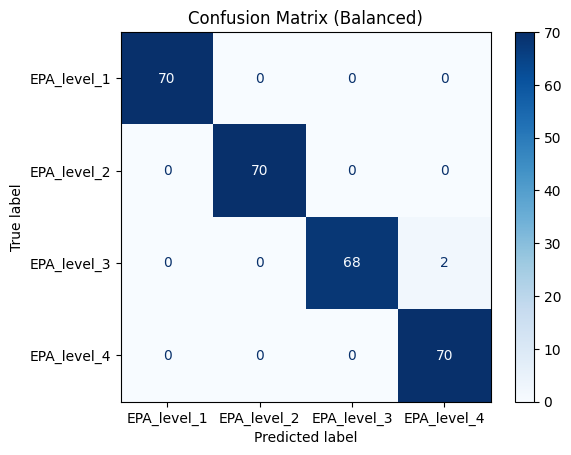

In [174]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Random Forest Classifier QTOFpos

In [175]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QTOFpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QTOFpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QTOFpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QTOFpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

EPA level counts in test_output_df3_QTOFpos_withEPA:
EPA_level_1     38
EPA_level_2    155
EPA_level_3    376
EPA_level_4    167
dtype: int64


In [176]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QTOFpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QTOFpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=5)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=5)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=5, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=5)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

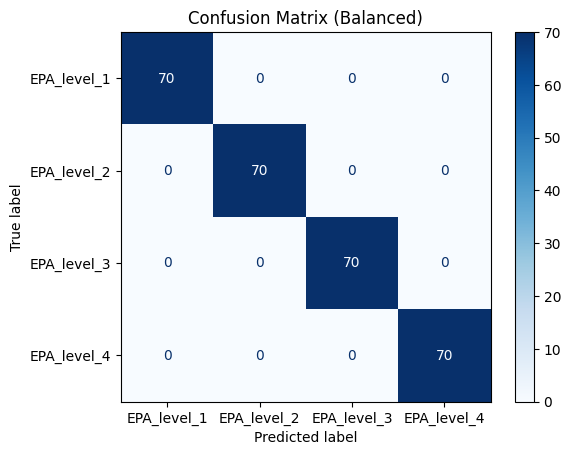

In [177]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Spectra to Toxicity MLP Architecture

In [178]:
batch_size = 128
epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10
#%%
# Everything below this line SHOULD be able to run without modification
class SpecToxMLP_Reg(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP_spectra(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP Training QQpos 

In [179]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_QQpos = train_data.copy()
test_data_df3_QQpos = test_data.copy()
val_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

In [180]:
# This isolates log response as the target varaible, not including embeddings at all.
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

In [181]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)


Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21871.0 MB
  Memory Used: 2345.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090


In [182]:
#%%
SpecToxMLP_df3_QQpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
SpecToxMLP_model_df3_QQpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

df3_QQpos_x_val = x_val

Epoch [1/1000]
   Training loss: 56.12856826782227
   Validation loss: 24.30002212524414
Epoch [2/1000]
   Training loss: 55.73216247558594
   Validation loss: 23.91889762878418
Epoch [3/1000]
   Training loss: 55.31738128662109
   Validation loss: 24.662221908569336
Epoch [4/1000]
   Training loss: 53.51945037841797
   Validation loss: 22.4039306640625
Epoch [5/1000]
   Training loss: 49.68304672241211
   Validation loss: 20.07326316833496
Epoch [6/1000]
   Training loss: 39.33638000488281
   Validation loss: 12.826364517211914
Epoch [7/1000]
   Training loss: 19.356321334838867
   Validation loss: 4.729145050048828
Epoch [8/1000]
   Training loss: 15.921448135375977
   Validation loss: 5.5922088623046875
Epoch [9/1000]
   Training loss: 10.146921253204345
   Validation loss: 3.9272408485412598
Epoch [10/1000]
   Training loss: 9.934286499023438
   Validation loss: 3.7867608070373535
Epoch [11/1000]
   Training loss: 8.134608840942382
   Validation loss: 2.4846081733703613
Epoch [12/1

### MLP Evaluation QQpos 

In [183]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = SpecToxMLP_model_df3_QQpos(df3_QQpos_x_val)  


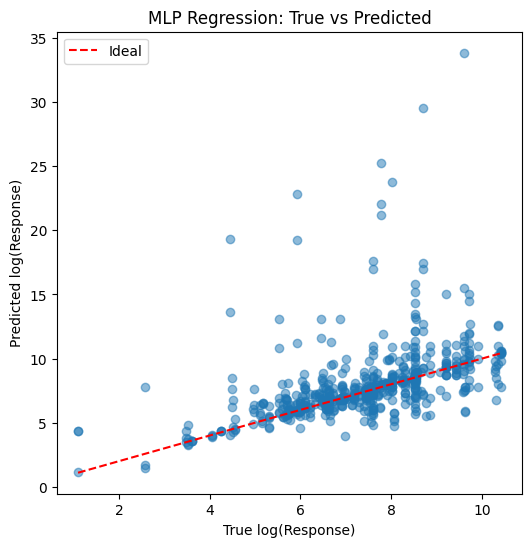

Mean Squared Error: 7.6697
R^2 Score: -1.9974


In [184]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

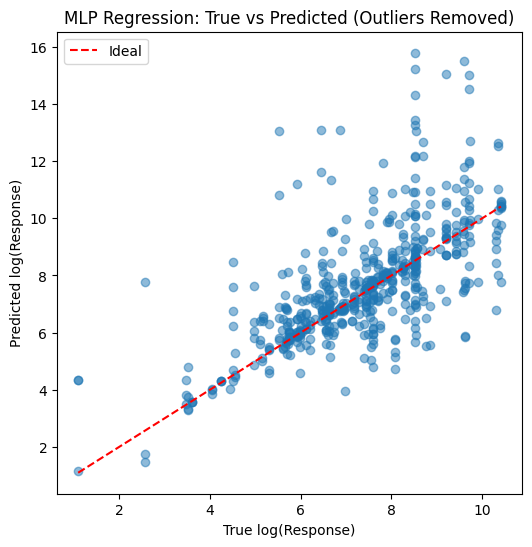

Mean Squared Error (filtered): 2.4414
R^2 Score (filtered): 0.0481


In [185]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

### Spectra MLP on super test set QQpos 

In [186]:
super_testing_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,676,677,678,679,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,273.642508,5.611823,0,1,0,0


In [187]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_QQpos.parameters()).device
add_response_and_log_response(super_testing_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

# Debug: Check what the model expects vs what we have
print(f"Super test dataset shape: {super_testing_df3_QQpos.shape}")
#print(f"Super test columns: {super_testing_df3_QQpos.columns.tolist()}")

# Get the expected input size from the model
model_input_size = next(SpecToxMLP_model_df3_QQpos.parameters()).shape[1]
print(f"Model expects input size: {model_input_size}")

# Use only numeric columns, excluding EPA levels and other non-spectral data
numeric_cols = super_testing_df3_QQpos.select_dtypes(include=[np.number]).columns.tolist()
# Remove EPA level columns and response columns
spectral_cols = [col for col in numeric_cols if not col.startswith('EPA_level_') 
                 and col not in ['Response', 'log_response']]

print(f"Available spectral columns: {len(spectral_cols)}")
print(f"First few spectral columns: {spectral_cols[:5]}")
print(f"Last few spectral columns: {spectral_cols[-5:]}")

# Take only the number of features the model expects
if len(spectral_cols) >= model_input_size:
    selected_cols = spectral_cols[:model_input_size]
    print(f"Using first {model_input_size} spectral columns")
else:
    selected_cols = spectral_cols
    print(f"Warning: Only {len(spectral_cols)} spectral columns available, but model expects {model_input_size}")

spectra_super = super_testing_df3_QQpos[selected_cols]
log_tox_val_super = super_testing_df3_QQpos['log_response']

print(f"Final spectra_super shape: {spectra_super.shape}")

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_QQpos(x_val_super_test)

Super test dataset shape: (89, 686)
Model expects input size: 679
Available spectral columns: 679
First few spectral columns: ['1', '2', '3', '4', '5']
Last few spectral columns: ['675', '676', '677', '678', '679']
Using first 679 spectral columns
Final spectra_super shape: (89, 679)


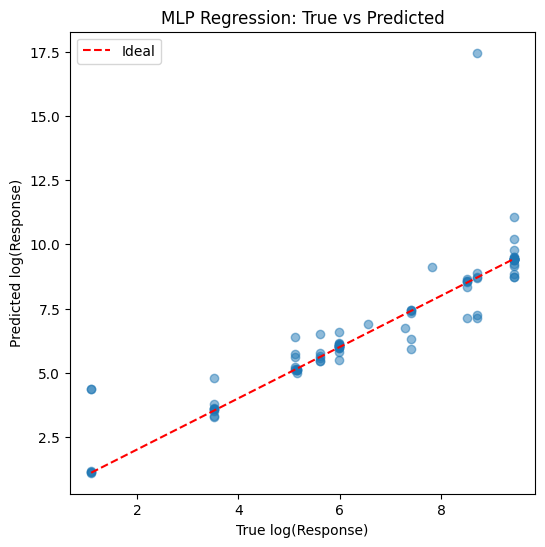

Mean Squared Error: 1.3542
R^2 Score: 0.7704


In [188]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


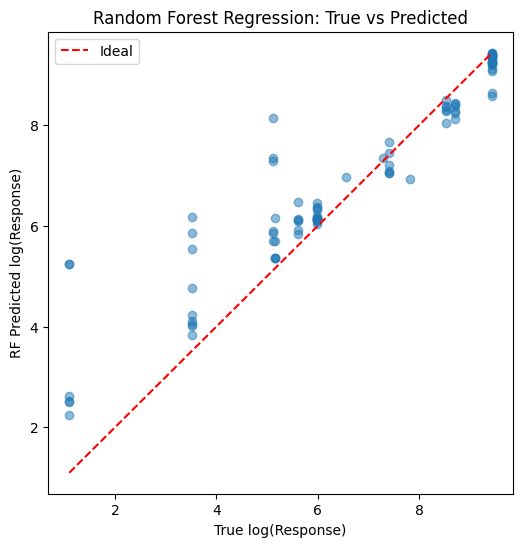

Random Forest Mean Squared Error: 1.0143
Random Forest R^2 Score: 0.8280


In [189]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg_QQpos = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_QQpos.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg_QQpos.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### Random forest regressor QQpos

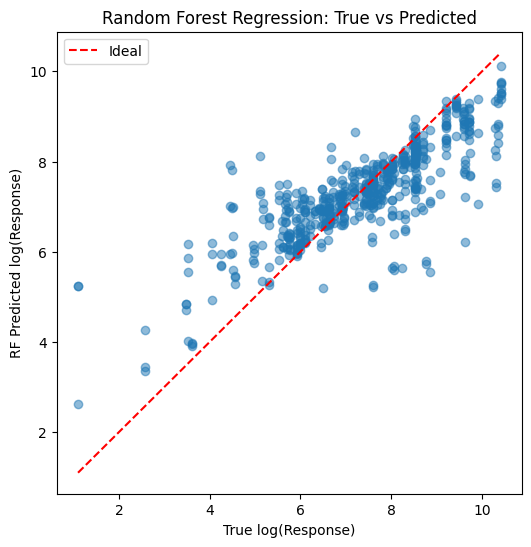

Random Forest Mean Squared Error: 0.9181
Random Forest R^2 Score: 0.6412


In [190]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training QTOFpos

In [191]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
df3_QTOFpos_spectra = add_response_and_log_response(df3_QTOFpos_spectra, df3_QTOFpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_QTOFpos = train_data.copy()
test_data_df3_QTOFpos = test_data.copy()
val_data = test_data_df3_QTOFpos

# Make a copy
train_data_df3_QTOFpos_copy = train_data.copy()
test_data_df3_QTOFpos_copy = test_data.copy()

In [192]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

#%%
SpecToxMLP_df3_QTOFpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
SpecToxMLP_model_df3_QTOFpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21863.0 MB
  Memory Used: 2353.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/1000]
   Training loss: 55.46051534016927
   Validation loss: 42.847042083740234
Epoch [2/1000]
   Training loss: 54.35159683227539
   Validation loss: 41.01047897338867
Epoch [3/1000]
   Training loss: 52.33476257324219
   Validation loss: 38.0418701171875
Epoch [4/1000]
   Training loss: 43.81656392415365
   Validation loss: 26.156047821044922
Epoch [5/1000]
   Training loss: 21.22949504852295
   Validation loss: 17.875680923461914
Epoch [6/1000]
   Training loss: 15.961905161539713
   Validation loss: 28.000944137573242
Epoch [7/1000]
   Training loss: 7.582368850708008
   Validation loss: 8.285059928894043
Epoch [8/1000]
   Training loss: 10.067208290100098
   Validation loss: 10.237064361572266
Epoch [9/1000]
   Training loss: 9.436874548594156
  

### MLP Evaluation QTOFpos

In [193]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = SpecToxMLP_model_df3_QTOFpos(x_val)


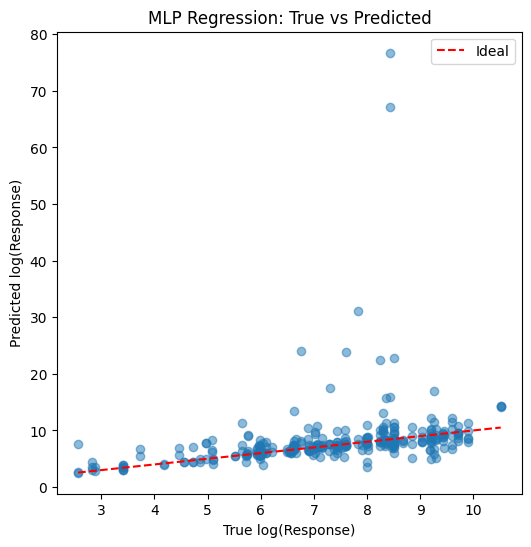

Mean Squared Error: 34.2968
R^2 Score: -10.7263


In [194]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QTOFpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

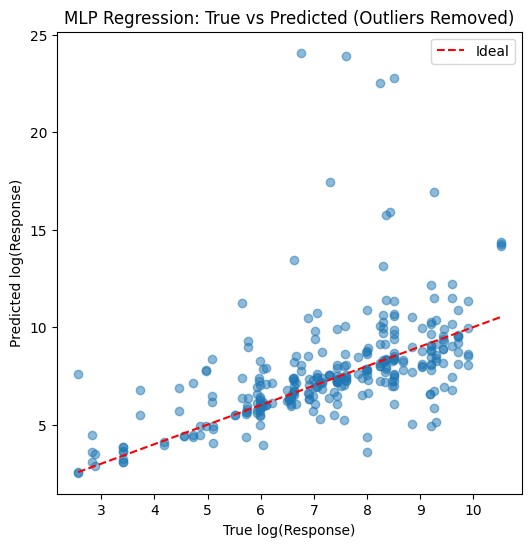

Mean Squared Error (filtered): 6.2382
R^2 Score (filtered): -1.1191


In [195]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QTOFpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

### Spectra MLP on QTOF super test set

In [196]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_QTOFpos.parameters()).device
add_response_and_log_response(super_testing_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

# Debug: Check what the model expects vs what we have
print(f"Super test dataset shape: {super_testing_df3_QTOFpos.shape}")
#print(f"Super test columns: {super_testing_df3_QTOFpos.columns.tolist()}")

# Get the expected input size from the model
model_input_size = next(SpecToxMLP_model_df3_QTOFpos.parameters()).shape[1]
print(f"Model expects input size: {model_input_size}")

# Use only numeric columns, excluding EPA levels and other non-spectral data
numeric_cols = super_testing_df3_QTOFpos.select_dtypes(include=[np.number]).columns.tolist()
# Remove EPA level columns and response columns
spectral_cols = [col for col in numeric_cols if not col.startswith('EPA_level_') 
                 and col not in ['Response', 'log_response']]

print(f"Available spectral columns: {len(spectral_cols)}")
print(f"First few spectral columns: {spectral_cols[:5]}")
print(f"Last few spectral columns: {spectral_cols[-5:]}")

# Take only the number of features the model expects
if len(spectral_cols) >= model_input_size:
    selected_cols = spectral_cols[:model_input_size]
    print(f"Using first {model_input_size} spectral columns")
else:
    selected_cols = spectral_cols
    print(f"Warning: Only {len(spectral_cols)} spectral columns available, but model expects {model_input_size}")

spectra_super = super_testing_df3_QTOFpos[selected_cols]
log_tox_val_super = super_testing_df3_QTOFpos['log_response']

print(f"Final spectra_super shape: {spectra_super.shape}")

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_QTOFpos(x_val_super_test)

Super test dataset shape: (61, 2005)
Model expects input size: 2001
Available spectral columns: 2002
First few spectral columns: ['1', '2', '3', '4', '5']
Last few spectral columns: ['1998', '1999', '2000', '2001', 'index']
Using first 2001 spectral columns
Final spectra_super shape: (61, 2001)


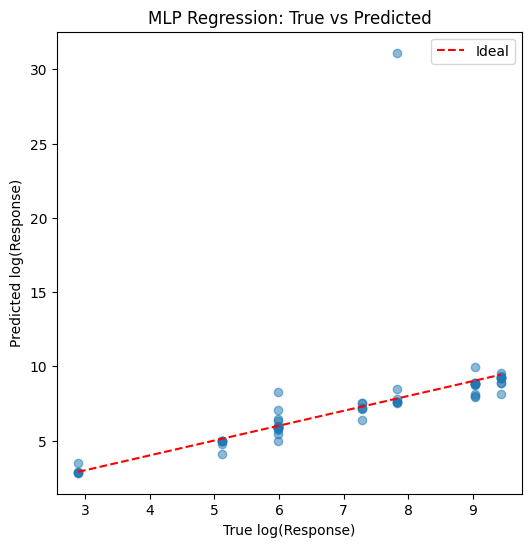

Mean Squared Error: 9.1859
R^2 Score: -1.4201


In [197]:
# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


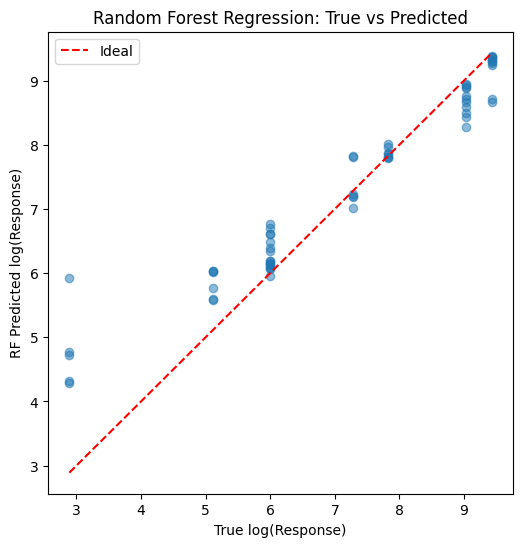

Random Forest Mean Squared Error: 0.4895
Random Forest R^2 Score: 0.8710


In [198]:
# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### Random Forest Regressor QTOFpos

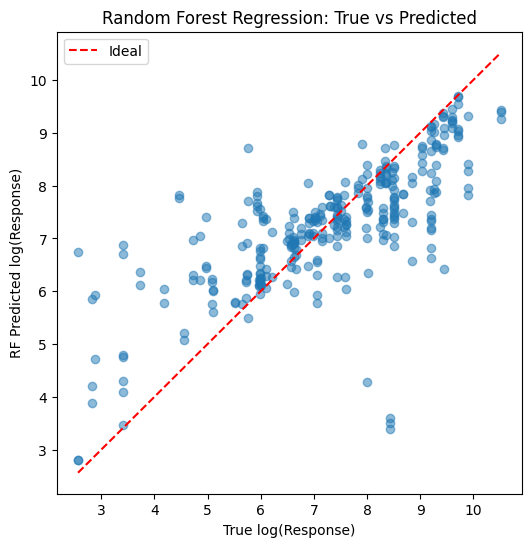

Random Forest Mean Squared Error: 1.3723
Random Forest R^2 Score: 0.5308


In [199]:
# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training LTQOpos

In [200]:
# Training and validation dataset split we need to add in response to the spectra.
df3_LTQOpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
df3_LTQOpos_spectra = add_response_and_log_response(df3_LTQOpos_spectra, df3_LTQOpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_LTQOpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_LTQOpos = train_data.copy()
test_data_df3_LTQOpos = test_data.copy()
val_data = test_data_df3_LTQOpos

# Make a copy
train_data_df3_LTQOpos_copy = train_data.copy()
test_data_df3_LTQOOpos_copy = test_data.copy()

In [201]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

#%%
SpecToxMLP_df3_LTQOpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
SpecToxMLP_model_df3_LTQOpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_LTQOpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

df3_LTQOpos_x_val = x_val
df3_LTQOpos_x_train = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21838.0 MB
  Memory Used: 2378.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/1000]
   Training loss: 56.83746910095215
   Validation loss: 59.22576141357422
Epoch [2/1000]
   Training loss: 56.88582801818848
   Validation loss: 60.19481658935547
Epoch [3/1000]
   Training loss: 56.75591278076172
   Validation loss: 59.82269287109375
Epoch [4/1000]
   Training loss: 56.51681327819824
   Validation loss: 58.73222351074219
Epoch [5/1000]
   Training loss: 56.36036491394043
   Validation loss: 58.507972717285156
Epoch [6/1000]
   Training loss: 56.129024505615234
   Validation loss: 58.23414611816406
Epoch [7/1000]
   Training loss: 55.621896743774414
   Validation loss: 56.526641845703125
Epoch [8/1000]
   Training loss: 55.23455238342285
   Validation loss: 56.51130676269531
Epoch [9/1000]
   Training loss: 54.56278038024902
   V

### MLP Evaluation LTQOpos

In [202]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_LTQOpos.eval()
with torch.no_grad():
    test_output_df3_LTQOpos = SpecToxMLP_model_df3_LTQOpos(df3_LTQOpos_x_val)


In [204]:
print(df3_LTQOpos_x_val.shape)
print(test_output_df3_LTQOpos.shape)
print(y_val_tox.shape) 
print(y_true.shape)
print(y_pred.shape)

torch.Size([233, 815])
torch.Size([233, 1])
torch.Size([233, 1])
(233,)
(308,)


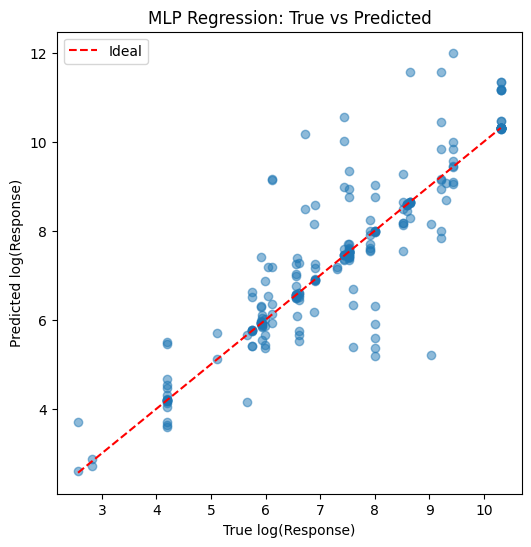

Mean Squared Error: 0.7467
R^2 Score: 0.7643


In [208]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_LTQOpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

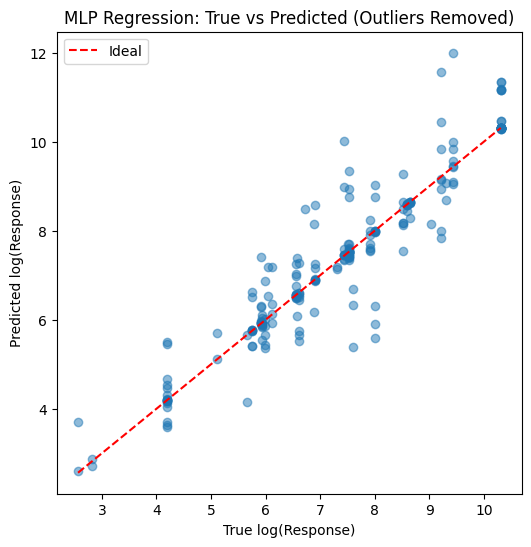

Mean Squared Error (filtered): 0.4260
R^2 Score (filtered): 0.8685


In [209]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_LTQOpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

### Spectra MLP on LTQOpos super test set

In [210]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_LTQOpos.parameters()).device
add_response_and_log_response(super_testing_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')

# Debug: Check what the model expects vs what we have
print(f"Super test dataset shape: {super_testing_df3_LTQOpos.shape}")
#print(f"Super test columns: {super_testing_df3_LTQOpos.columns.tolist()}")

# Get the expected input size from the model
model_input_size = next(SpecToxMLP_model_df3_LTQOpos.parameters()).shape[1]
print(f"Model expects input size: {model_input_size}")

# Use only numeric columns, excluding EPA levels and other non-spectral data
numeric_cols = super_testing_df3_LTQOpos.select_dtypes(include=[np.number]).columns.tolist()
# Remove EPA level columns and response columns
spectral_cols = [col for col in numeric_cols if not col.startswith('EPA_level_') 
                 and col not in ['Response', 'log_response']]

print(f"Available spectral columns: {len(spectral_cols)}")
print(f"First few spectral columns: {spectral_cols[:5]}")
print(f"Last few spectral columns: {spectral_cols[-5:]}")

# Take only the number of features the model expects
if len(spectral_cols) >= model_input_size:
    selected_cols = spectral_cols[:model_input_size]
    print(f"Using first {model_input_size} spectral columns")
else:
    selected_cols = spectral_cols
    print(f"Warning: Only {len(spectral_cols)} spectral columns available, but model expects {model_input_size}")

spectra_super = super_testing_df3_LTQOpos[selected_cols]
log_tox_val_super = super_testing_df3_LTQOpos['log_response']

print(f"Final spectra_super shape: {spectra_super.shape}")

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_LTQOpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_LTQOpos(x_val_super_test)

Super test dataset shape: (96, 819)
Model expects input size: 815
Available spectral columns: 816
First few spectral columns: ['1', '2', '3', '4', '5']
Last few spectral columns: ['812', '813', '814', '815', 'index']
Using first 815 spectral columns
Final spectra_super shape: (96, 815)


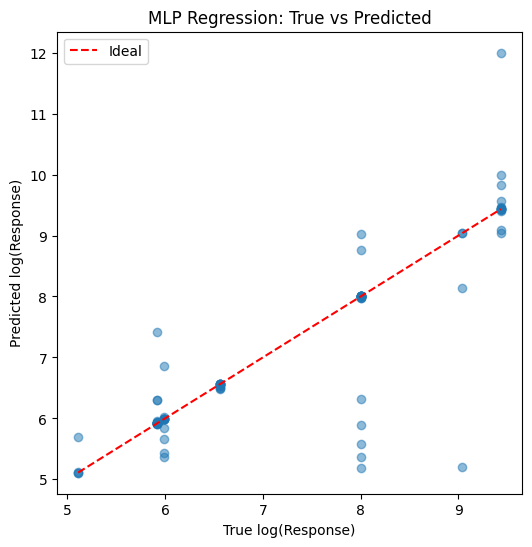

Mean Squared Error: 0.5934
R^2 Score: 0.6906


In [211]:
# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


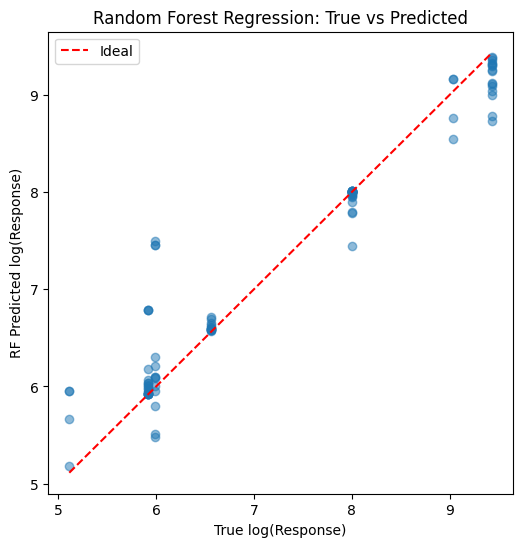

Random Forest Mean Squared Error: 0.1450
Random Forest R^2 Score: 0.9244


In [212]:
# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### Random Forest Regressor LTQOpos

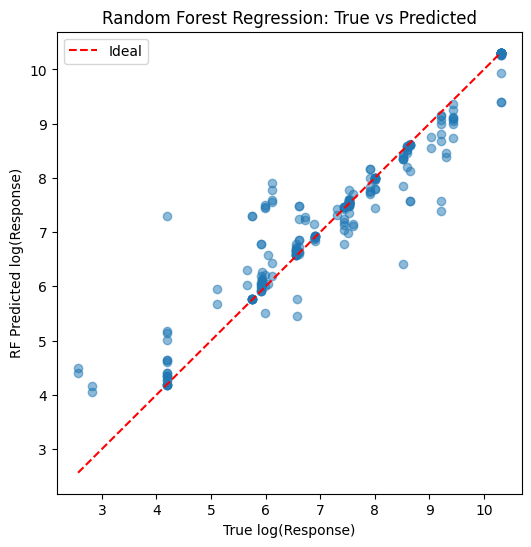

Random Forest Mean Squared Error: 0.3224
Random Forest R^2 Score: 0.8982


In [213]:
# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg_LTQOpos = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_LTQOpos.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg_LTQOpos.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# ChemNet --> Toxicity MLP and Random Forest

### Processing to/of ChemNet Embeddings

In [214]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-6].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)

encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



In [215]:
# Encoder excecution df3_QTOFpos
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Encoder excecution df3_QTOFpos super testing
x_super_df3_QTOFpos = super_testing_df3_QTOFpos.iloc[:, 1:-3].values
x_super_tensor_df3_QTOFpos = torch.tensor(x_super_df3_QTOFpos, dtype=torch.float32).to(x_val_df3_QTOFpos.device)
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    super_test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_super_tensor_df3_QTOFpos)


In [216]:
# Encoder excecution df3_LTQOpos
encoder_df3_LTQOpos.eval()
with torch.no_grad():
    test_output_df3_LTQOpos = encoder_df3_LTQOpos(x_val_df3_LTQOpos)

with torch.no_grad():
    train_output_df3_LTQOpos = encoder_df3_LTQOpos(x_train_df3_LTQOpos)

# Encoder excecution df3_QTOFpos super testing
x_super_df3_LTQOpos = super_testing_df3_LTQOpos.iloc[:, 1:-3].values
x_super_tensor_df3_LTQOpos = torch.tensor(x_super_df3_LTQOpos, dtype=torch.float32).to(x_val_df3_LTQOpos.device)
encoder_df3_LTQOpos.eval()
with torch.no_grad():
    super_test_output_df3_LTQOpos = encoder_df3_LTQOpos(x_super_tensor_df3_LTQOpos)


In [217]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Ensure indices match before assignment
test_output_df3_QQpos = test_output_df3_QQpos.reset_index(drop=True)
test_data_df3_QQpos_copy = test_data_df3_QQpos_copy.reset_index(drop=True)
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']

train_output_df3_QQpos = train_output_df3_QQpos.reset_index(drop=True)
train_data_df3_QQpos_copy = train_data_df3_QQpos_copy.reset_index(drop=True)
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']


In [218]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])

# Ensure indices match before assignment
test_output_df3_QTOFpos = test_output_df3_QTOFpos.reset_index(drop=True)
test_data_df3_QTOFpos_copy = test_data_df3_QTOFpos_copy.reset_index(drop=True)
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos_copy['SMILES_spectra']

train_output_df3_QTOFpos = train_output_df3_QTOFpos.reset_index(drop=True)
train_data_df3_QTOFpos_copy = train_data_df3_QTOFpos_copy.reset_index(drop=True)
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos_copy['SMILES_spectra']

In [219]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_LTQOpos_np = test_output_df3_LTQOpos.cpu().numpy()
train_output_df3_LTQOpos_np = train_output_df3_LTQOpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_LTQOpos = pd.DataFrame(test_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_LTQOpos_np.shape[1])])
train_output_df3_LTQOpos = pd.DataFrame(train_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_LTQOpos_np.shape[1])])

# Ensure indices match before assignment
test_output_df3_LTQOpos = test_output_df3_LTQOpos.reset_index(drop=True)
test_data_df3_LTQOpos_copy = test_data_df3_LTQOpos_copy.reset_index(drop=True)
test_output_df3_LTQOpos['SMILES_spectra'] = test_data_df3_LTQOpos_copy['SMILES_spectra']

train_output_df3_LTQOpos = train_output_df3_LTQOpos.reset_index(drop=True)
train_data_df3_LTQOpos_copy = train_data_df3_LTQOpos_copy.reset_index(drop=True)
train_output_df3_LTQOpos['SMILES_spectra'] = train_data_df3_LTQOpos_copy['SMILES_spectra']

In [220]:
# Add the 'Response' values to the test and train outputs
# def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
#     """
#     Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
#     """
#     # Create mapping from SMILES to Response
#     smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
#     output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
#     return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

test_output_df3_QTOFpos = add_response_and_log_response(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_and_log_response(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

test_output_df3_LTQOpos = add_response_and_log_response(test_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')
train_output_df3_LTQOpos = add_response_and_log_response(train_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')


In [221]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    #df.drop(columns=[response_col], inplace=True)
    return df

# Use it
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

test_output_df3_QTOFpos_withEPA = add_epa_levels(test_output_df3_QTOFpos)
train_output_df3_QTOFpos_withEPA = add_epa_levels(train_output_df3_QTOFpos)

test_output_df3_LTQOpos_withEPA = add_epa_levels(test_output_df3_LTQOpos)
train_output_df3_LTQOpos_withEPA = add_epa_levels(train_output_df3_LTQOpos)

In [222]:
# Process encoder outputs for super test set
# QQpos
super_test_output_df3_QQpos_np = super_test_output_df3_QQpos.cpu().numpy()
super_test_output_df3_QQpos_df = pd.DataFrame(
    super_test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQpos_np.shape[1])]
)
super_test_output_df3_QQpos_df['SMILES_spectra'] = super_testing_df3_QQpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_QQpos_df = add_response_and_log_response(super_test_output_df3_QQpos_df, df3_QQpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_QQpos_withEPA = add_epa_levels(super_test_output_df3_QQpos_df)


In [223]:
# QTOFpos
super_test_output_df3_QTOFpos_np = super_test_output_df3_QTOFpos.cpu().numpy()
super_test_output_df3_QTOFpos_df = pd.DataFrame(
    super_test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QTOFpos_np.shape[1])]
)
super_test_output_df3_QTOFpos_df['SMILES_spectra'] = super_testing_df3_QTOFpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_QTOFpos_df = add_response_and_log_response(super_test_output_df3_QTOFpos_df, df3_QTOFpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_QTOFpos_withEPA = add_epa_levels(super_test_output_df3_QTOFpos_df)

In [224]:
# LTQOpos
super_test_output_df3_LTQOpos_np = super_test_output_df3_LTQOpos.cpu().numpy()
super_test_output_df3_LTQOpos_df = pd.DataFrame(
    super_test_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_LTQOpos_np.shape[1])]
)
super_test_output_df3_LTQOpos_df['SMILES_spectra'] = super_testing_df3_LTQOpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_LTQOpos_df = add_response_and_log_response(super_test_output_df3_LTQOpos_df, df3_LTQOpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_LTQOpos_withEPA = add_epa_levels(super_test_output_df3_LTQOpos_df)

### Random Forests

In [225]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QQpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     16
EPA_level_2    117
EPA_level_3    308
EPA_level_4     97
dtype: int64


In [226]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [227]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QQpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

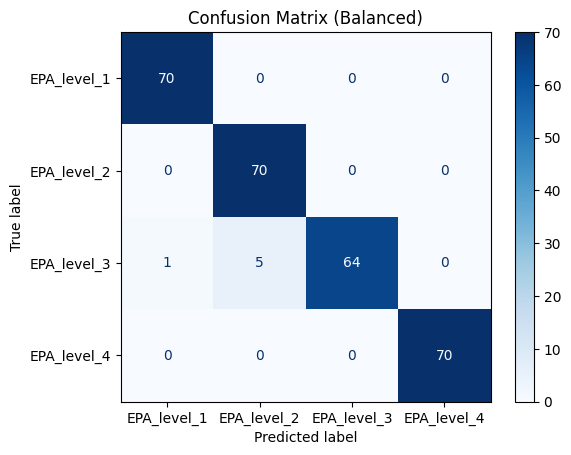

In [228]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

In [229]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QTOFpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QTOFpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QTOFpos_withEPA:
EPA_level_1     17
EPA_level_2     68
EPA_level_3    150
EPA_level_4     44
dtype: int64


In [230]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QTOFpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [231]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QTOFpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QTOFpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

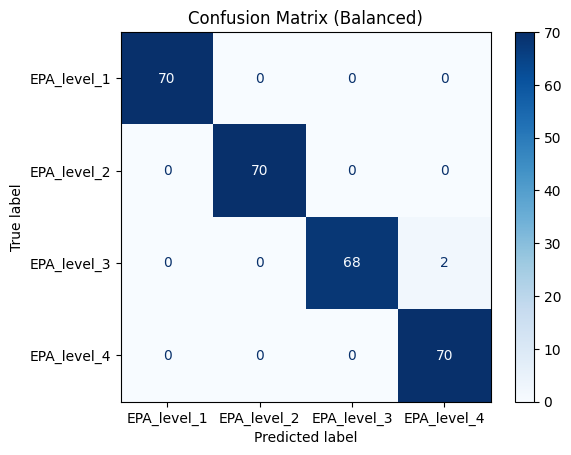

In [232]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Random Forest on super test set

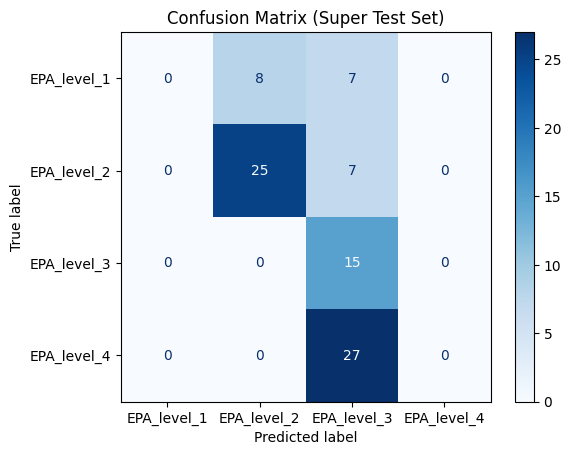

In [233]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QQpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

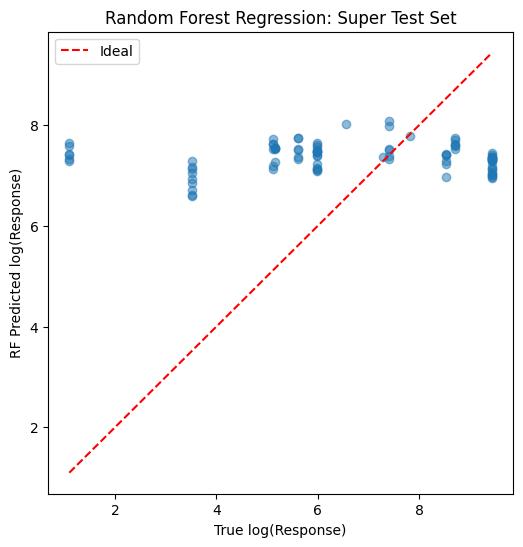

Super Test Set Mean Squared Error: 6.5298
Super Test Set R^2 Score: -0.1073


In [234]:
# Now the same but with the random forest regressor
# Prepare X and y for train and test sets (ChemNet embeddings)
embedding_cols = [col for col in train_output_df3_QQpos.columns if col.startswith('Embedding Float')]
X_train_rf = train_output_df3_QQpos[embedding_cols].values
y_train_rf = train_output_df3_QQpos['log_response'].values

X_test_rf = test_output_df3_QQpos[embedding_cols].values
y_test_rf = test_output_df3_QQpos['log_response'].values

# Combine train and test for training
X_rf = np.vstack([X_train_rf, X_test_rf])
y_rf = np.concatenate([y_train_rf, y_test_rf])

# Prepare super test set
X_super_rf = super_test_output_df3_QQpos_withEPA[embedding_cols].values
y_super_rf = super_test_output_df3_QQpos_withEPA['log_response'].values

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)

# Predict on super test set
y_pred_super_rf = rf_reg.predict(X_super_rf)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_super_rf, y_pred_super_rf, alpha=0.5)
plt.plot([y_super_rf.min(), y_super_rf.max()], [y_super_rf.min(), y_super_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: Super Test Set')
plt.legend()
plt.show()

# Quantitative metrics
mse_super = mean_squared_error(y_super_rf, y_pred_super_rf)
r2_super = r2_score(y_super_rf, y_pred_super_rf)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

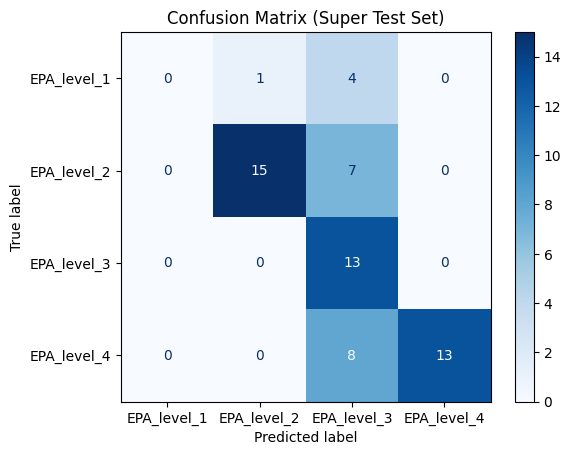

In [235]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QTOFpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QTOFpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QTOFpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QTOFpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

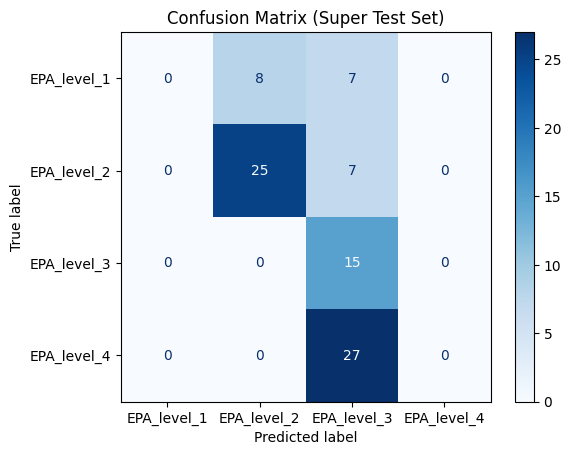

In [236]:
# Define spectra columns for super test set (exclude non-numeric and EPA columns)
spectra_cols = [
    col for col in super_test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES_spectra'] + [col for col in super_test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
X_super = super_test_output_df3_QQpos_withEPA[spectra_cols].select_dtypes(include=[np.number])
y_super = super_test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Predict and plot confusion matrix
y_pred_super = rf_bal.predict(X_super)
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

### MLP Data Processing

In [237]:
# Encoder excecution 
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')


# Add an index for bette integration into the MLP algorithm
test_output_df3_QQpos['index'] = test_output_df3_QQpos.index
train_output_df3_QQpos['index'] = train_output_df3_QQpos.index

# Save a copy
test_output_df3_QQpos_copy = test_output_df3_QQpos.copy()
train_output_df3_QQpos_copy = train_output_df3_QQpos.copy()

In [238]:
# Encoder excecution 
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)  

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos_copy['SMILES_spectra']
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QTOFpos = add_response_and_log_response(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_and_log_response(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')


# Add an index for better integration into the MLP algorithm
test_output_df3_QTOFpos['index'] = test_output_df3_QTOFpos.index
train_output_df3_QTOFpos['index'] = train_output_df3_QTOFpos.index

# Save a copy
test_output_df3_QTOFpos_copy = test_output_df3_QTOFpos.copy()
train_output_df3_QTOFpos_copy = train_output_df3_QTOFpos.copy()

In [239]:
print(test_output_df3_QQpos.shape)
test_output_df3_QQpos.head()

(538, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.174264,-0.032460,0.074226,0.058487,-0.108206,0.314235,-0.347546,-0.088305,-0.054455,-0.303933,...,-0.419674,-0.016891,0.075759,0.075030,-0.021697,-0.154556,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.025150,0.012358,0.012011,-0.151472,-0.128610,0.063886,-0.167716,-0.212140,-0.254779,-0.135223,...,-0.415168,-0.085506,-0.088655,-0.141521,0.047750,-0.343428,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.231761,-0.046931,0.233838,-0.308641,-0.110516,-0.000022,-0.197871,-0.138529,-0.327765,-0.358485,...,-0.238194,-0.014063,0.174943,0.501258,0.307326,-0.038186,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.069868,-0.026751,-0.002473,-0.084236,-0.083512,0.218229,-0.360976,-0.161459,-0.139034,-0.490879,...,-0.548638,-0.073945,0.047541,-0.054952,0.032923,-0.300561,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,-0.198065,0.013681,0.064991,-0.511802,-0.115383,0.012350,-0.116042,-0.273650,-0.301623,-0.223033,...,-0.249427,0.001754,0.015423,0.324474,0.207343,-0.092969,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


In [240]:
print(train_output_df3_QQpos.shape)
train_output_df3_QQpos.head()

(564, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.112783,0.008218,-0.034467,-0.112381,-0.037900,0.045318,-0.233246,-0.177816,-0.208345,-0.556260,...,-0.503987,-0.146678,-0.013251,-0.206984,0.074366,-0.330683,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.122597,0.007531,-0.024905,-0.116236,-0.045973,0.039165,-0.231825,-0.160223,-0.206373,-0.552479,...,-0.502061,-0.146252,-0.005699,-0.210486,0.077107,-0.325476,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.120783,0.002357,-0.023533,-0.102893,-0.041973,0.027045,-0.232214,-0.161990,-0.197596,-0.559138,...,-0.501243,-0.151095,0.013998,-0.198477,0.060193,-0.329000,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.120164,0.004026,-0.028863,-0.090162,-0.042051,0.035718,-0.237130,-0.169066,-0.190458,-0.568631,...,-0.502777,-0.145923,0.004694,-0.209829,0.066717,-0.325720,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,-0.124553,0.002276,-0.020588,-0.111067,-0.053173,0.032117,-0.242140,-0.156264,-0.195968,-0.540222,...,-0.490624,-0.130659,0.005467,-0.213766,0.049321,-0.329494,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


### MLP Architecture

In [241]:
# The genreal architecture of the MLP will be the same as that of the encoder, the main difference between the two is that the MLP will 
# have a 1 dimensional output, the true Response values of each SMILES, and we will use those SMILES to track which repsonse value belongs 
# with each Chemical.
# We will also adjust the input so that we have the log(response) rather than just response as our varaible of interest.

#%%
epochs=100
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 5
#%%

# Everything below this line SHOULD be able to run without modification
class ToxMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP Data Prep

In [242]:
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-4]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

def create_dataset_tensors_tox_spec(spectra_dataset,device, start_idx=None, stop_idx=None):

    embedding_cols = [col for col in spectra_dataset.columns if col.startswith('Embedding Float')]
    spectra = spectra_dataset[embedding_cols]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### MLP Training QQpos

In the training process we should combine the set, resplit them as we have done in the past then we can train and evaulate the model. 

In [243]:
combined_output_df3_QQpos = pd.concat([train_output_df3_QQpos, test_output_df3_QQpos], ignore_index=True)
print(combined_output_df3_QQpos.shape)
combined_output_df3_QQpos.head()

(1102, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.112783,0.008218,-0.034467,-0.112381,-0.037900,0.045318,-0.233246,-0.177816,-0.208345,-0.556260,...,-0.503987,-0.146678,-0.013251,-0.206984,0.074366,-0.330683,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.122597,0.007531,-0.024905,-0.116236,-0.045973,0.039165,-0.231825,-0.160223,-0.206373,-0.552479,...,-0.502061,-0.146252,-0.005699,-0.210486,0.077107,-0.325476,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.120783,0.002357,-0.023533,-0.102893,-0.041973,0.027045,-0.232214,-0.161990,-0.197596,-0.559138,...,-0.501243,-0.151095,0.013998,-0.198477,0.060193,-0.329000,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.120164,0.004026,-0.028863,-0.090162,-0.042051,0.035718,-0.237130,-0.169066,-0.190458,-0.568631,...,-0.502777,-0.145923,0.004694,-0.209829,0.066717,-0.325720,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,-0.124553,0.002276,-0.020588,-0.111067,-0.053173,0.032117,-0.242140,-0.156264,-0.195968,-0.540222,...,-0.490624,-0.130659,0.005467,-0.213766,0.049321,-0.329494,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


In [244]:
# Generalize the syntax
dataset = combined_output_df3_QQpos

train_indices = []
test_indices = []

for smiles, group in dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = dataset.loc[train_indices].reset_index(drop=True)
test_data = dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
#train_data['index'] = train_data.index
#test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_output_df3_QQpos = train_data.copy()
test_output_df3_QQpos = test_data.copy()
val_data = test_output_df3_QQpos

# Make a copy
train_output_df3_QQpos_copy = train_data.copy()
test_output_df3_QQpos_copy = test_data.copy()

In [245]:
print(train_output_df3_QQpos.shape)
train_output_df3_QQpos.head()

(566, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.112783,0.008218,-0.034467,-0.112381,-0.037900,0.045318,-0.233246,-0.177816,-0.208345,-0.556260,...,-0.503987,-0.146678,-0.013251,-0.206984,0.074366,-0.330683,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.231761,-0.046931,0.233838,-0.308641,-0.110516,-0.000022,-0.197871,-0.138529,-0.327765,-0.358485,...,-0.238194,-0.014063,0.174943,0.501258,0.307326,-0.038186,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
2,-0.120783,0.002357,-0.023533,-0.102893,-0.041973,0.027045,-0.232214,-0.161990,-0.197596,-0.559138,...,-0.501243,-0.151095,0.013998,-0.198477,0.060193,-0.329000,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.198065,0.013681,0.064991,-0.511802,-0.115383,0.012350,-0.116042,-0.273650,-0.301623,-0.223033,...,-0.249427,0.001754,0.015423,0.324474,0.207343,-0.092969,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4
4,-0.124553,0.002276,-0.020588,-0.111067,-0.053173,0.032117,-0.242140,-0.156264,-0.195968,-0.540222,...,-0.490624,-0.130659,0.005467,-0.213766,0.049321,-0.329494,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


In [246]:
# MLP training
device = f.set_up_gpu()

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox_spec(
    train_output_df3_QQpos, device, start_idx=2, stop_idx=-0)
del train_output_df3_QQpos

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox_spec(
    test_output_df3_QQpos, device, start_idx=2, stop_idx=-0)
del test_output_df3_QQpos


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21832.0 MB
  Memory Used: 2384.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [247]:
print(x_train.shape, y_train_tox.shape, train_indices_tensor.shape)

torch.Size([566, 512]) torch.Size([566, 1]) torch.Size([566])


In [248]:

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QQpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QQpos = train_model_MLP(
    model=toxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Epoch [1/100]
   Training loss: 56.254415893554686
   Validation loss: 24.10199546813965
Epoch [2/100]
   Training loss: 55.05271759033203
   Validation loss: 22.585046768188477
Epoch [3/100]
   Training loss: 54.48933563232422
   Validation loss: 22.154834747314453
Epoch [4/100]
   Training loss: 54.35258026123047
   Validation loss: 22.502944946289062
Epoch [5/100]
   Training loss: 54.11178359985352
   Validation loss: 22.82380485534668


Epoch [6/100]
   Training loss: 52.40597839355469
   Validation loss: 20.87188148498535
Epoch [7/100]
   Training loss: 52.19014358520508
   Validation loss: 22.045751571655273
Epoch [8/100]
   Training loss: 50.016563415527344
   Validation loss: 20.712793350219727
Epoch [9/100]
   Training loss: 46.482259368896486
   Validation loss: 18.5463924407959
Epoch [10/100]
   Training loss: 41.84211044311523
   Validation loss: 16.511198043823242
Epoch [11/100]
   Training loss: 34.67226638793945
   Validation loss: 12.670231819152832
Epoch [12/100]
   Training loss: 26.20051383972168
   Validation loss: 9.560864448547363
Epoch [13/100]
   Training loss: 15.910464477539062
   Validation loss: 4.972806453704834
Epoch [14/100]
   Training loss: 7.417251682281494
   Validation loss: 2.295553684234619
Epoch [15/100]
   Training loss: 4.826636409759521
   Validation loss: 2.3752102851867676
Epoch [16/100]
   Training loss: 6.154591178894043
   Validation loss: 2.2709789276123047
Epoch [17/100]
  

### MLP Evaluation QQpos

In [249]:
# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_QQpos = toxMLP_df3_QQpos(x_val) 

# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_QQpos = toxMLP_df3_QQpos(x_train)  
 

In [250]:
print(x_val.shape)

torch.Size([536, 512])


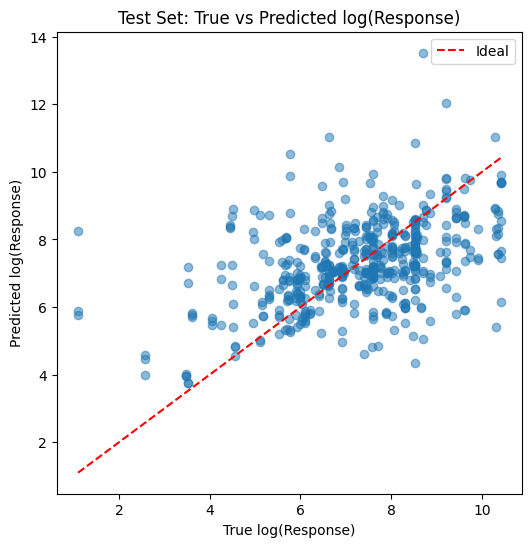

Test Set Mean Squared Error: 2.2706
Test Set R^2 Score: 0.0999


In [251]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Use the correct source for true values
y_true_test = test_output_df3_QQpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


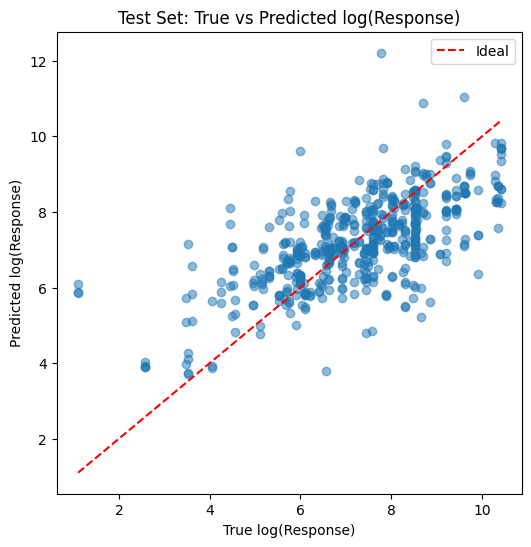

Train Set Mean Squared Error: 1.4388
Train Set R^2 Score: 0.4341


In [252]:
# Use the correct source for true values
y_true_train = train_output_df3_QQpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### MLP on the super test set QQpos

In [253]:
print(super_test_output_df3_QQpos_withEPA.shape)
super_test_output_df3_QQpos_withEPA.head()

(89, 519)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,-0.024115,-0.031632,-0.016412,0.254570,-0.184354,0.199878,-0.325822,-0.379494,-0.230387,-0.285554,...,-0.132305,-0.099134,0.264092,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0,1,0,0
1,-0.025999,-0.035145,-0.000866,0.253765,-0.180306,0.195924,-0.338176,-0.384124,-0.229291,-0.301748,...,-0.131158,-0.100082,0.248877,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0,1,0,0
2,-0.025081,-0.035912,0.001518,0.252889,-0.183289,0.192607,-0.338468,-0.387100,-0.233107,-0.315507,...,-0.123731,-0.101450,0.245074,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0,1,0,0
3,-0.030448,-0.030343,-0.001888,0.230483,-0.192036,0.189918,-0.338501,-0.390062,-0.241425,-0.321737,...,-0.122394,-0.105932,0.252250,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0,1,0,0
4,-0.041546,0.010349,-0.071487,-0.006132,-0.306983,0.154817,-0.281298,-0.410511,-0.308271,-0.298114,...,-0.139920,-0.127502,0.361732,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0,1,0,0


Training data shape: torch.Size([566, 512])
Super test set shape: (89, 512)
Number of embedding columns in super test set: 512
MLP model expects input size: 512
Super test set has: 512 features
Final super test set shape: (89, 512)


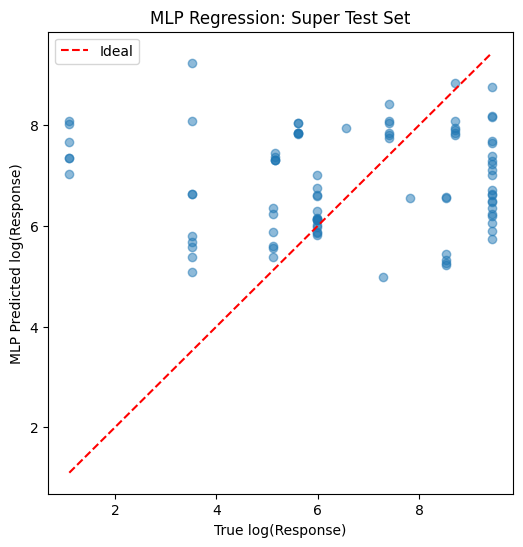

Super Test Set Mean Squared Error: 6.9030
Super Test Set R^2 Score: -0.1706


In [254]:
# --- ChemNet MLP: Predict and evaluate on super test set (NO retraining) ---

# Prepare X for the super test set (ChemNet embeddings)
embedding_cols = [col for col in super_test_output_df3_QQpos_withEPA.columns if col.startswith('Embedding Float')]
X_super = super_test_output_df3_QQpos_withEPA[embedding_cols].values
y_super = super_test_output_df3_QQpos_withEPA['log_response'].values

# Debug information
print(f"Training data shape: {x_train.shape}")
print(f"Super test set shape: {X_super.shape}")
print(f"Number of embedding columns in super test set: {len(embedding_cols)}")
print(f"MLP model expects input size: {x_train.shape[1]}")
print(f"Super test set has: {X_super.shape[1]} features")

# Check if we need to adjust the feature size
if X_super.shape[1] != x_train.shape[1]:
    print(f"Shape mismatch! Need to adjust from {X_super.shape[1]} to {x_train.shape[1]} features")
    
    # Option 1: Truncate the super test set to match training data size
    if X_super.shape[1] > x_train.shape[1]:
        print("Truncating super test set to match training data size")
        X_super = X_super[:, :x_train.shape[1]]
    
    # Option 2: Pad the super test set if it's smaller (unlikely in this case)
    elif X_super.shape[1] < x_train.shape[1]:
        print("Padding super test set to match training data size")
        padding = np.zeros((X_super.shape[0], x_train.shape[1] - X_super.shape[1]))
        X_super = np.concatenate([X_super, padding], axis=1)

print(f"Final super test set shape: {X_super.shape}")

# Convert to tensor and move to device
x_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(device)

# Predict with the already-trained MLP
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    y_pred_super = MLP_model_df3_QQpos(x_super_tensor).cpu().numpy().flatten()

# Visualization and metrics
plt.figure(figsize=(6,6))
plt.scatter(y_super, y_pred_super, alpha=0.5)
plt.plot([y_super.min(), y_super.max()], [y_super.min(), y_super.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('MLP Predicted log(Response)')
plt.title('MLP Regression: Super Test Set')
plt.legend()
plt.show()

mse_super = mean_squared_error(y_super, y_pred_super)
r2_super = r2_score(y_super, y_pred_super)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

### Random forest regressor QQpos

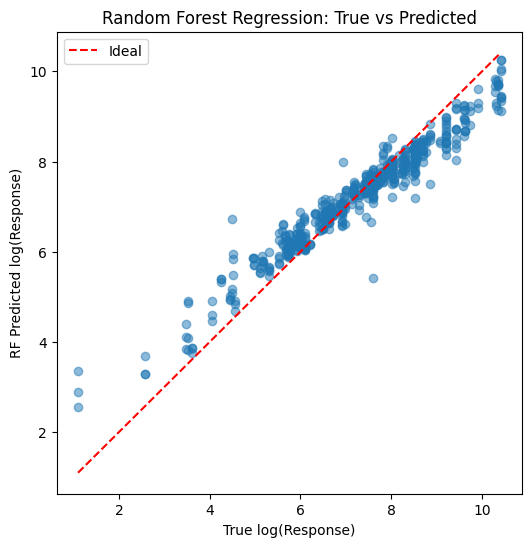

Random Forest Mean Squared Error: 0.2520
Random Forest R^2 Score: 0.9001


In [255]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_QQpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_QQpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)
y_pred_rf = rf_reg.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training QTOFpos

In [256]:
combined_output_df3_QTOFpos = pd.concat([train_output_df3_QTOFpos, test_output_df3_QTOFpos], ignore_index=True)
print(combined_output_df3_QTOFpos.shape)
combined_output_df3_QTOFpos.head()

(577, 516)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,0.347112,0.004865,0.005463,0.302698,-0.166461,0.072756,-0.373460,-0.768969,-0.573838,-0.346650,...,-0.098730,-0.049625,0.003287,0.633622,0.325404,-0.239812,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,1463.00000,7.288244,0
1,0.348798,0.008163,0.002097,0.304042,-0.165778,0.074080,-0.376044,-0.768856,-0.575271,-0.341481,...,-0.098756,-0.048137,0.001666,0.629963,0.321718,-0.240001,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,1463.00000,7.288244,1
2,0.629169,0.003896,-0.256101,-0.146067,-0.375379,0.017909,0.599031,-0.233671,-0.199270,-0.498598,...,-0.792703,-0.170054,0.570860,0.403353,-0.695962,0.413006,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,1463.00000,7.288244,2
3,0.627485,0.001171,-0.256557,-0.143372,-0.383595,0.013580,0.603713,-0.230916,-0.201000,-0.503368,...,-0.787246,-0.170128,0.581913,0.407149,-0.701067,0.415764,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,3
4,-0.248909,0.084142,0.291883,0.784377,-0.227905,0.296493,-0.349640,-0.052016,-0.009432,-0.714869,...,-0.647726,-0.070202,0.870294,0.548963,-0.340142,-0.466907,C=CCN(CC=C)C(=O)C(Cl)Cl,1989.75212,7.595765,4


In [257]:
# Generalize the syntax
dataset = combined_output_df3_QTOFpos

train_indices = []
test_indices = []

for smiles, group in dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = dataset.loc[train_indices].reset_index(drop=True)
test_data = dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
#train_data['index'] = train_data.index
#test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_output_df3_QTOFpos = train_data.copy()
test_output_df3_QTOFpos = test_data.copy()
val_data = test_output_df3_QTOFpos

# Make a copy
train_output_df3_QTOFpos_copy = train_data.copy()
test_output_df3_QTOFpos_copy = test_data.copy()

In [258]:
# MLP training
device = f.set_up_gpu()

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox_spec(
    train_output_df3_QTOFpos, device, start_idx=2, stop_idx=-0)
del train_output_df3_QTOFpos

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox_spec(
    test_output_df3_QTOFpos, device, start_idx=2, stop_idx=-0)
del test_output_df3_QTOFpos


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21832.0 MB
  Memory Used: 2384.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [259]:
train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QTOFpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QTOFpos = train_model_MLP(
    model=toxMLP_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Epoch [1/100]
   Training loss: 50.06977971394857
   Validation loss: 34.69866180419922
Epoch [2/100]
   Training loss: 52.24304072062174
   Validation loss: 38.171932220458984
Epoch [3/100]
   Training loss: 52.20414606730143
   Validation loss: 38.298885345458984
Epoch [4/100]
   Training loss: 52.01994959513346
   Validation loss: 38.218414306640625
Epoch [5/100]
   Training loss: 51.77381388346354
   Validation loss: 38.07182312011719
Epoch [6/100]
   Training loss: 50.628004709879555
   Validation loss: 36.606239318847656
Epoch [7/100]
   Training loss: 50.772979736328125
   Validation loss: 37.158416748046875
Epoch [8/100]
   Training loss: 49.11916478474935
   Validation loss: 35.095375061035156
Epoch [9/100]
   Training loss: 47.813655853271484
   Validation loss: 33.676937103271484
Epoch [10/100]
   Training loss: 46.694952646891274
   Validation loss: 32.7312126159668
Epoch [11/100]
   Training loss: 45.63010025024414
   Validation loss: 32.11781311035156
Epoch [12/100]
   Tr

Epoch [84/100]
   Training loss: 2.4542834758758545
   Validation loss: 1.4189116954803467
Epoch [85/100]
   Training loss: 2.284573952356974
   Validation loss: 1.2003631591796875
Epoch [86/100]
   Training loss: 2.525895675023397
   Validation loss: 1.6119611263275146
Epoch [87/100]
   Training loss: 2.426816940307617
   Validation loss: 1.5107187032699585
Epoch [88/100]
   Training loss: 2.580434719721476
   Validation loss: 1.7624492645263672
Epoch [89/100]
   Training loss: 2.4773314793904624
   Validation loss: 1.6133294105529785
Epoch [90/100]
   Training loss: 2.3150061766306558
   Validation loss: 1.3749339580535889
Epoch [91/100]
   Training loss: 2.268835266431173
   Validation loss: 1.3310974836349487
Epoch [92/100]
   Training loss: 2.4651222229003906
   Validation loss: 1.6390025615692139
Epoch [93/100]
   Training loss: 2.379533608754476
   Validation loss: 1.5464999675750732
Epoch [94/100]
   Training loss: 2.19534703095754
   Validation loss: 1.2893943786621094
Epoch [

### MLP Evaluation QTOFpos

In [260]:
# Excecution
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_QTOFpos = toxMLP_df3_QTOFpos(x_val) 

# Excecution
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_QTOFpos = toxMLP_df3_QTOFpos(x_train)


y_true_test shape: (278,)
y_pred_test shape: (278,)
test_output_df3_QTOFpos_copy shape: (278, 516)
After alignment: y_true=278, y_pred=278


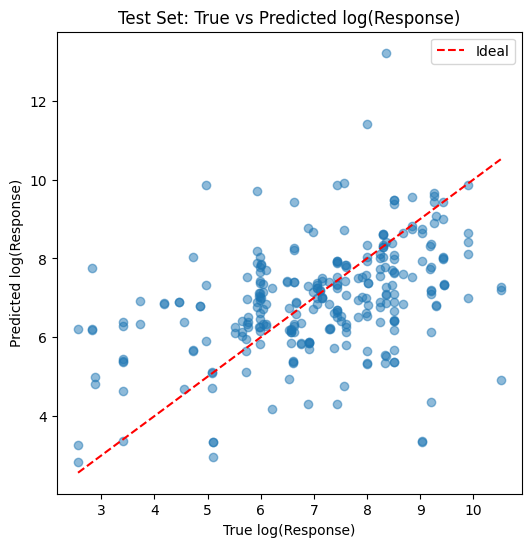

Test Set Mean Squared Error: 2.7814
Test Set R^2 Score: 0.0060


In [261]:
# Use the correct source for true values
y_true_test = test_output_df3_QTOFpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_QTOFpos.cpu().numpy().flatten()

# DEBUG: Check sizes
print(f"y_true_test shape: {y_true_test.shape}")
print(f"y_pred_test shape: {y_pred_test.shape}")
print(f"test_output_df3_QTOFpos_copy shape: {test_output_df3_QTOFpos_copy.shape}")

# FIX: Align the arrays to the same size
min_length = min(len(y_true_test), len(y_pred_test))
y_true_test = y_true_test[:min_length]
y_pred_test = y_pred_test[:min_length]

print(f"After alignment: y_true={len(y_true_test)}, y_pred={len(y_pred_test)}")

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


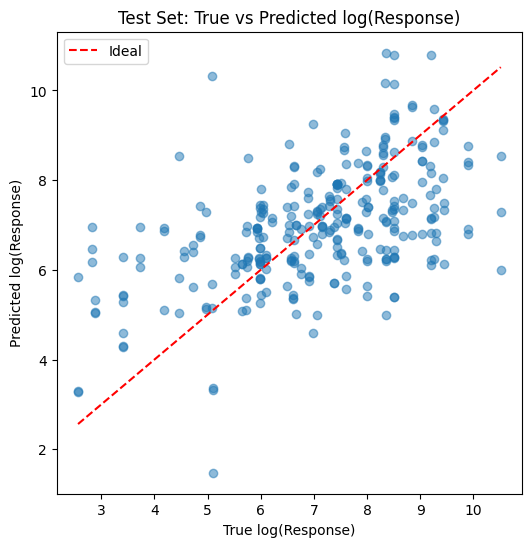

Train Set Mean Squared Error: 2.2051
Train Set R^2 Score: 0.2254


In [262]:
# Use the correct source for true values
y_true_train = train_output_df3_QTOFpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_QTOFpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### MLP on super test set QTOFpos

Training data shape: torch.Size([299, 512])
Super test set shape: (61, 512)
Number of embedding columns in super test set: 512
MLP model expects input size: 512
Super test set has: 512 features
Final super test set shape: (61, 512)


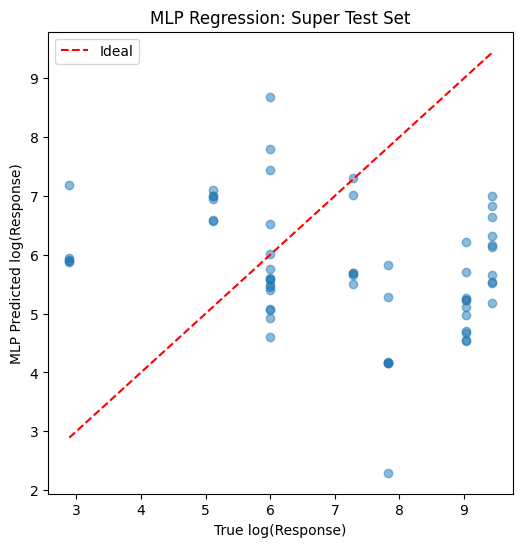

Super Test Set Mean Squared Error: 7.9515
Super Test Set R^2 Score: -1.0949


In [263]:
# --- ChemNet MLP: Predict and evaluate on super test set (NO retraining) ---

# Prepare X for the super test set (ChemNet embeddings)
embedding_cols = [col for col in super_test_output_df3_QTOFpos_withEPA.columns if col.startswith('Embedding Float')]
X_super = super_test_output_df3_QTOFpos_withEPA[embedding_cols].values
y_super = super_test_output_df3_QTOFpos_withEPA['log_response'].values

# Debug information
print(f"Training data shape: {x_train.shape}")
print(f"Super test set shape: {X_super.shape}")
print(f"Number of embedding columns in super test set: {len(embedding_cols)}")
print(f"MLP model expects input size: {x_train.shape[1]}")
print(f"Super test set has: {X_super.shape[1]} features")

# Check if we need to adjust the feature size
if X_super.shape[1] != x_train.shape[1]:
    print(f"Shape mismatch! Need to adjust from {X_super.shape[1]} to {x_train.shape[1]} features")
    
    # Option 1: Truncate the super test set to match training data size
    if X_super.shape[1] > x_train.shape[1]:
        print("Truncating super test set to match training data size")
        X_super = X_super[:, :x_train.shape[1]]
    
    # Option 2: Pad the super test set if it's smaller (unlikely in this case)
    elif X_super.shape[1] < x_train.shape[1]:
        print("Padding super test set to match training data size")
        padding = np.zeros((X_super.shape[0], x_train.shape[1] - X_super.shape[1]))
        X_super = np.concatenate([X_super, padding], axis=1)

print(f"Final super test set shape: {X_super.shape}")

# Convert to tensor and move to device
x_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(device)

# Predict with the already-trained MLP
MLP_model_df3_QTOFpos.eval()
with torch.no_grad():
    y_pred_super = MLP_model_df3_QTOFpos(x_super_tensor).cpu().numpy().flatten()

# Visualization and metrics
plt.figure(figsize=(6,6))
plt.scatter(y_super, y_pred_super, alpha=0.5)
plt.plot([y_super.min(), y_super.max()], [y_super.min(), y_super.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('MLP Predicted log(Response)')
plt.title('MLP Regression: Super Test Set')
plt.legend()
plt.show()

mse_super = mean_squared_error(y_super, y_pred_super)
r2_super = r2_score(y_super, y_pred_super)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

### Random forest regressor QTOFpos

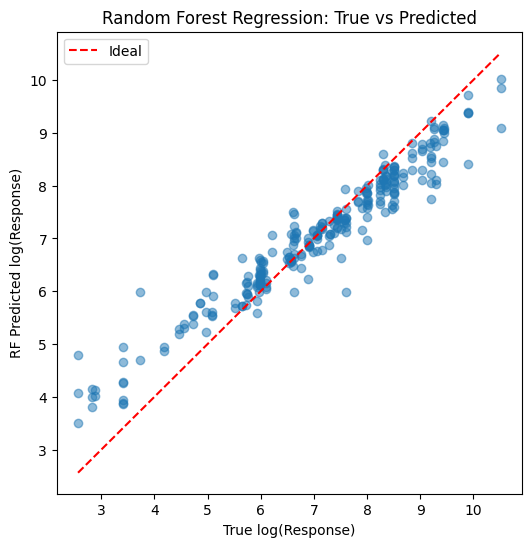

Random Forest Mean Squared Error: 0.3183
Random Forest R^2 Score: 0.8863


In [264]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_QTOFpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_QTOFpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)
y_pred_rf = rf_reg.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Training LTQOpos

In [265]:
combined_output_df3_LTQOpos = pd.concat([train_output_df3_LTQOpos, test_output_df3_LTQOpos], ignore_index=True)
print(combined_output_df3_LTQOpos.shape)
combined_output_df3_LTQOpos.head()

(376, 515)


,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response
0,0.196945,0.063708,-0.426188,-0.544538,-0.105248,0.023981,-0.245214,-0.147474,-0.022147,-0.239589,...,-0.002297,-0.676430,-0.095637,0.027543,0.471771,-0.104039,0.014117,C1CCC(CC1)NC1CCCCC1,373.0,5.921578
1,0.192867,0.063943,-0.428006,-0.542983,-0.109448,0.027678,-0.244808,-0.144018,-0.020675,-0.236089,...,-0.001070,-0.677712,-0.094708,0.029750,0.470692,-0.106686,0.015485,C1CCC(CC1)NC1CCCCC1,373.0,5.921578
2,0.033999,-0.003229,-0.427190,0.031851,-0.093020,0.018715,-0.115290,-0.081583,-0.153109,-0.403070,...,-0.001480,-0.561578,-0.054578,0.259630,0.087131,0.067741,0.216247,C1CCC(CC1)NC1CCCCC1,373.0,5.921578
3,0.040279,0.000034,-0.433729,0.028518,-0.098639,0.017354,-0.119677,-0.078638,-0.152369,-0.408255,...,-0.003617,-0.559283,-0.051935,0.256301,0.086795,0.074496,0.212445,C1CCC(CC1)NC1CCCCC1,373.0,5.921578
4,0.116558,0.004178,-0.356679,0.089080,-0.014948,0.089429,-0.327108,-0.100597,-0.021360,-0.734404,...,-0.002715,-0.345800,-0.034226,-0.304940,0.338166,0.281012,0.455122,C1CCC(CC1)NC1CCCCC1,373.0,5.921578


In [268]:
# Generalize the syntax
dataset = combined_output_df3_LTQOpos

train_indices = []
test_indices = []

for smiles, group in dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = dataset.loc[train_indices].reset_index(drop=True)
test_data = dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_output_df3_LTQOpos = train_data.copy()
test_output_df3_LTQOpos = test_data.copy()
val_data = test_output_df3_LTQOpos

# Make a copy
train_output_df3_LTQOpos_copy = train_data.copy()
test_output_df3_LTQOpos_copy = test_data.copy()

In [269]:
# MLP training
device = f.set_up_gpu()

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox_spec(
    train_output_df3_LTQOpos, device, start_idx=2, stop_idx=-0)
del train_output_df3_LTQOpos

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox_spec(
    test_output_df3_LTQOpos, device, start_idx=2, stop_idx=-0)
del test_output_df3_LTQOpos


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21832.0 MB
  Memory Used: 2384.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [271]:
train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_LTQOpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_LTQOpos = train_model_MLP(
    model=toxMLP_df3_LTQOpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)


Epoch [1/100]
   Training loss: 56.94901657104492
   Validation loss: 62.5261344909668
Epoch [2/100]
   Training loss: 55.24395751953125
   Validation loss: 59.251895904541016
Epoch [3/100]
   Training loss: 54.72623062133789
   Validation loss: 58.40147399902344
Epoch [4/100]
   Training loss: 54.869821548461914
   Validation loss: 58.89105987548828
Epoch [5/100]
   Training loss: 54.80172920227051
   Validation loss: 58.953102111816406
Epoch [6/100]
   Training loss: 55.05117988586426
   Validation loss: 59.6717529296875
Epoch [7/100]
   Training loss: 54.29915237426758
   Validation loss: 58.36244201660156
Epoch [8/100]
   Training loss: 53.756797790527344
   Validation loss: 57.50153350830078
Epoch [9/100]
   Training loss: 53.7232551574707
   Validation loss: 57.714698791503906
Epoch [10/100]
   Training loss: 53.7216739654541
   Validation loss: 58.05180358886719
Epoch [11/100]
   Training loss: 51.87539100646973
   Validation loss: 54.68232345581055
Epoch [12/100]
   Training lo

### MLP Evaluation LTQOpos

In [272]:
# Excecution
MLP_model_df3_LTQOpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_LTQOpos = toxMLP_df3_LTQOpos(x_val) 

# Excecution
MLP_model_df3_LTQOpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_LTQOpos = toxMLP_df3_LTQOpos(x_train)


y_true_test shape: (183,)
y_pred_test shape: (183,)
test_output_df3_LTQOpos_copy shape: (183, 516)
After alignment: y_true=183, y_pred=183


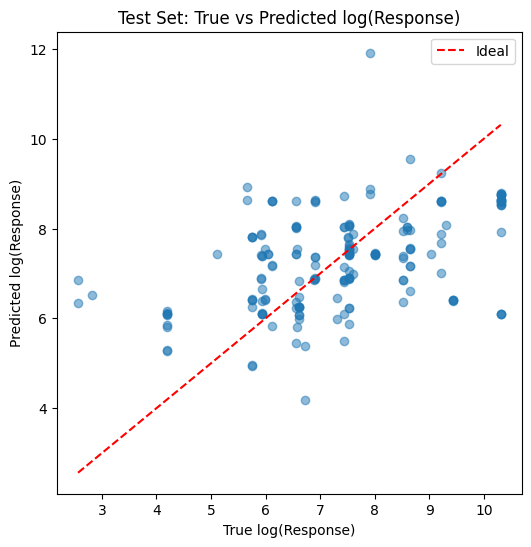

Test Set Mean Squared Error: 2.2784
Test Set R^2 Score: 0.1796


In [273]:
# Use the correct source for true values
y_true_test = test_output_df3_LTQOpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_LTQOpos.cpu().numpy().flatten()

# DEBUG: Check sizes
print(f"y_true_test shape: {y_true_test.shape}")
print(f"y_pred_test shape: {y_pred_test.shape}")
print(f"test_output_df3_LTQOpos_copy shape: {test_output_df3_LTQOpos_copy.shape}")

# FIX: Align the arrays to the same size
min_length = min(len(y_true_test), len(y_pred_test))
y_true_test = y_true_test[:min_length]
y_pred_test = y_pred_test[:min_length]

print(f"After alignment: y_true={len(y_true_test)}, y_pred={len(y_pred_test)}")

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


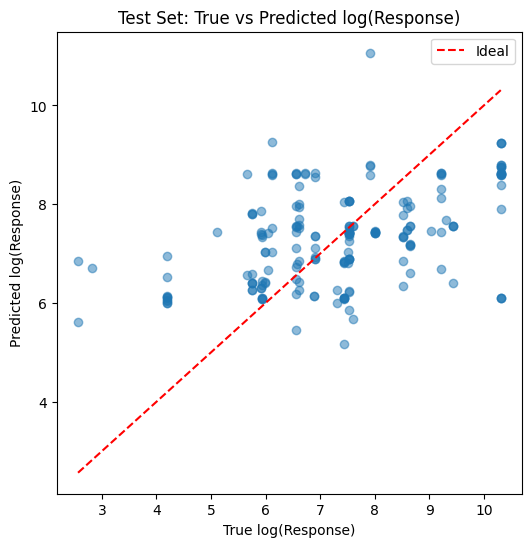

Train Set Mean Squared Error: 2.1994
Train Set R^2 Score: 0.2027


In [274]:
# Use the correct source for true values
y_true_train = train_output_df3_LTQOpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_LTQOpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### MLP on super test set LTQOpos

Training data shape: torch.Size([193, 512])
Super test set shape: (96, 512)
Number of embedding columns in super test set: 512
MLP model expects input size: 512
Super test set has: 512 features
Final super test set shape: (96, 512)


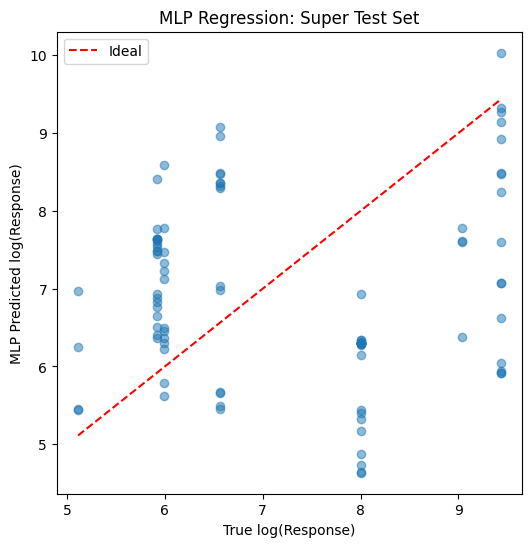

Super Test Set Mean Squared Error: 3.2091
Super Test Set R^2 Score: -0.6733


In [275]:
# --- ChemNet MLP: Predict and evaluate on super test set (NO retraining) ---

# Prepare X for the super test set (ChemNet embeddings)
embedding_cols = [col for col in super_test_output_df3_LTQOpos_withEPA.columns if col.startswith('Embedding Float')]
X_super = super_test_output_df3_LTQOpos_withEPA[embedding_cols].values
y_super = super_test_output_df3_LTQOpos_withEPA['log_response'].values

# Debug information
print(f"Training data shape: {x_train.shape}")
print(f"Super test set shape: {X_super.shape}")
print(f"Number of embedding columns in super test set: {len(embedding_cols)}")
print(f"MLP model expects input size: {x_train.shape[1]}")
print(f"Super test set has: {X_super.shape[1]} features")

# Check if we need to adjust the feature size
if X_super.shape[1] != x_train.shape[1]:
    print(f"Shape mismatch! Need to adjust from {X_super.shape[1]} to {x_train.shape[1]} features")
    
    # Option 1: Truncate the super test set to match training data size
    if X_super.shape[1] > x_train.shape[1]:
        print("Truncating super test set to match training data size")
        X_super = X_super[:, :x_train.shape[1]]
    
    # Option 2: Pad the super test set if it's smaller (unlikely in this case)
    elif X_super.shape[1] < x_train.shape[1]:
        print("Padding super test set to match training data size")
        padding = np.zeros((X_super.shape[0], x_train.shape[1] - X_super.shape[1]))
        X_super = np.concatenate([X_super, padding], axis=1)

print(f"Final super test set shape: {X_super.shape}")

# Convert to tensor and move to device
x_super_tensor = torch.tensor(X_super, dtype=torch.float32).to(device)

# Predict with the already-trained MLP
MLP_model_df3_LTQOpos.eval()
with torch.no_grad():
    y_pred_super = MLP_model_df3_LTQOpos(x_super_tensor).cpu().numpy().flatten()

# Visualization and metrics
plt.figure(figsize=(6,6))
plt.scatter(y_super, y_pred_super, alpha=0.5)
plt.plot([y_super.min(), y_super.max()], [y_super.min(), y_super.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('MLP Predicted log(Response)')
plt.title('MLP Regression: Super Test Set')
plt.legend()
plt.show()

mse_super = mean_squared_error(y_super, y_pred_super)
r2_super = r2_score(y_super, y_pred_super)
print(f"Super Test Set Mean Squared Error: {mse_super:.4f}")
print(f"Super Test Set R^2 Score: {r2_super:.4f}")

### Random Forest Regressor LTQOpos

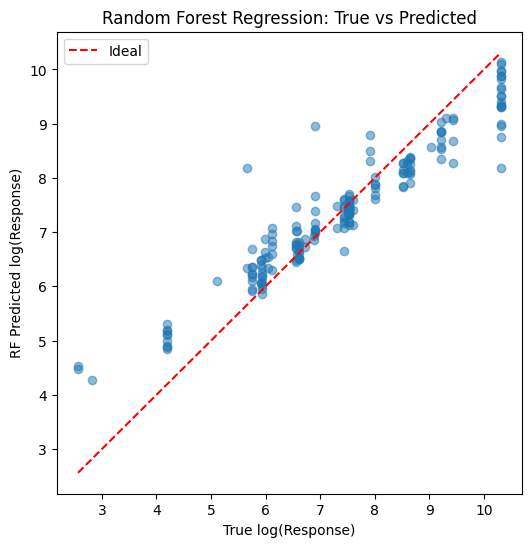

Random Forest Mean Squared Error: 0.3835
Random Forest R^2 Score: 0.8619


In [276]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_LTQOpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_LTQOpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg_LTQOpos = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_LTQOpos.fit(X_rf, y_rf)
y_pred_rf = rf_reg_LTQOpos.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# Spectra --> ChemNet AND Toxicity Conditional Encoder

### Architecture

In [277]:
batch_size = 64
epochs=500
lr=0.0001
criterion1=nn.MSELoss()
criterion2=nn.MSELoss()
output_size = 513
num_layers = 8

#%%
# Encoder architecture (With Validation Set)
class Cond_Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_condenc(model, train_data, val_data, epochs, learning_rate, criterion1, criterion2, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_combined = model(batch) # Take the first 512 for criterion 1 and the last for criterion 2, look up to make sure i only apply the loss to the subset of the model
            
            # Embedding Loss
            batch_predicted_embeddings = batch_predicted_combined[:, :512] # First 512 columns
            loss1 = criterion1(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss)
            # Response Loss
            batch_predicted_log_tox = batch_predicted_combined[:, 512:] # Last column
            loss2 = criterion2(batch_predicted_log_tox, true_log_tox) # loss2 (toxicity loss)
            
            total_loss = loss1 + loss2
            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():  # Condense this as we did above for symmetry tho not needed without loss.backward command
            for val_batch, val_true_embeddings, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted = model(val_batch)
                val_batch_predicted_embeddings = val_batch_predicted[:, :512]

                val_loss = criterion1(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss1.item()

                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_tox.to(device)

                val_batch_predicted_tox = val_batch_predicted[:, 512:]

                val_loss = criterion2(val_batch_predicted_tox, val_true_tox)
                val_loss += loss2.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training and Testing set construction

In [278]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

In [279]:
# Add the 'Response' and 'log_response' columns to df3_QQpos_spectra
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

In [280]:
df3_QQpos_spectra.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,672,673,674,675,676,677,678,679,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823


In [281]:
# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data_df3_QQpos = add_response_and_log_response(train_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')
test_data_df3_QQpos = add_response_and_log_response(test_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')

# Make a copy
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 683)
(579, 683)


In [282]:
smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 683)
After removal, test shape: (538, 683)
Super testing set shape: (86, 683)
Any left in train? False
Any left in test? False


In [283]:
test_data_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,673,674,675,676,677,678,679,Response,log_response,index
11,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4825.080312,8.481583,11
12,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4825.080312,8.481583,12
13,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4825.080312,8.481583,13
14,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4825.080312,8.481583,14
15,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4825.080312,8.481583,15


In [284]:
def create_dataset_tensors_emb_tox(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true embeddings, true toxicity values, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, log_tox_tensor, spectra_tensor, spectra_indices_tensor 

In [285]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_emb, y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_emb_tox(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_emb, y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_emb_tox(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_emb, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_emb, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
cond_encoder_df3_QQpos = Cond_Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
cond_encoder_model_df3_QQpos = train_model_condenc(
    model=cond_encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion1=criterion1,
    criterion2=criterion2,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21830.0 MB
  Memory Used: 2386.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


Epoch [1/500]
   Training loss: 53.90324058532715
   Validation loss: 9.50437068939209
Epoch [2/500]
   Training loss: 26.928678607940675
   Validation loss: 0.9458101391792297
Epoch [3/500]
   Training loss: 10.404068326950073
   Validation loss: 1.4277479648590088
Epoch [4/500]
   Training loss: 6.996240711212158
   Validation loss: 0.7971658110618591
Epoch [5/500]
   Training loss: 4.575104904174805
   Validation loss: 0.47556039690971375
Epoch [6/500]
   Training loss: 3.5589227437973023
   Validation loss: 0.472748726606369
Epoch [7/500]
   Training loss: 2.892801284790039
   Validation loss: 0.5960088968276978
Epoch [8/500]
   Training loss: 2.4715337991714477
   Validation loss: 0.5216750502586365
Epoch [9/500]
   Training loss: 2.0730035066604615
   Validation loss: 0.4423936903476715
Epoch [10/500]
   Training loss: 1.742330753803253
   Validation loss: 0.3154498338699341
Epoch [11/500]
   Training loss: 1.5206005096435546
   Validation loss: 0.3274078071117401
Epoch [12/500]


In [286]:
# Generate the output of the conditional encoder for visulatization and evaulation
# Generate output from the conditional encoder
cond_encoder_model_df3_QQpos.eval()
with torch.no_grad():
    cond_encoder_output = cond_encoder_model_df3_QQpos(x_val)

# Separate the output into ChemNet embeddings (first 512) and toxicity prediction (last 1)
chemnet_output = cond_encoder_output[:, :512].cpu().numpy()  # First 512 dimensions
tox_output = cond_encoder_output[:, 512:].cpu().numpy().flatten()  # Last dimension

print(f"ChemNet output shape: {chemnet_output.shape}")
print(f"Toxicity output shape: {tox_output.shape}")

# True ChemNet embeddings 
true_chemnet_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
true_chemnet_embeddings = true_chemnet_df.iloc[:, 1:513].values  # Assuming columns 1-512 are embeddings
true_smiles = true_chemnet_df['SMILES'].values  # Adjust column name if different


ChemNet output shape: (579, 512)
Toxicity output shape: (579,)


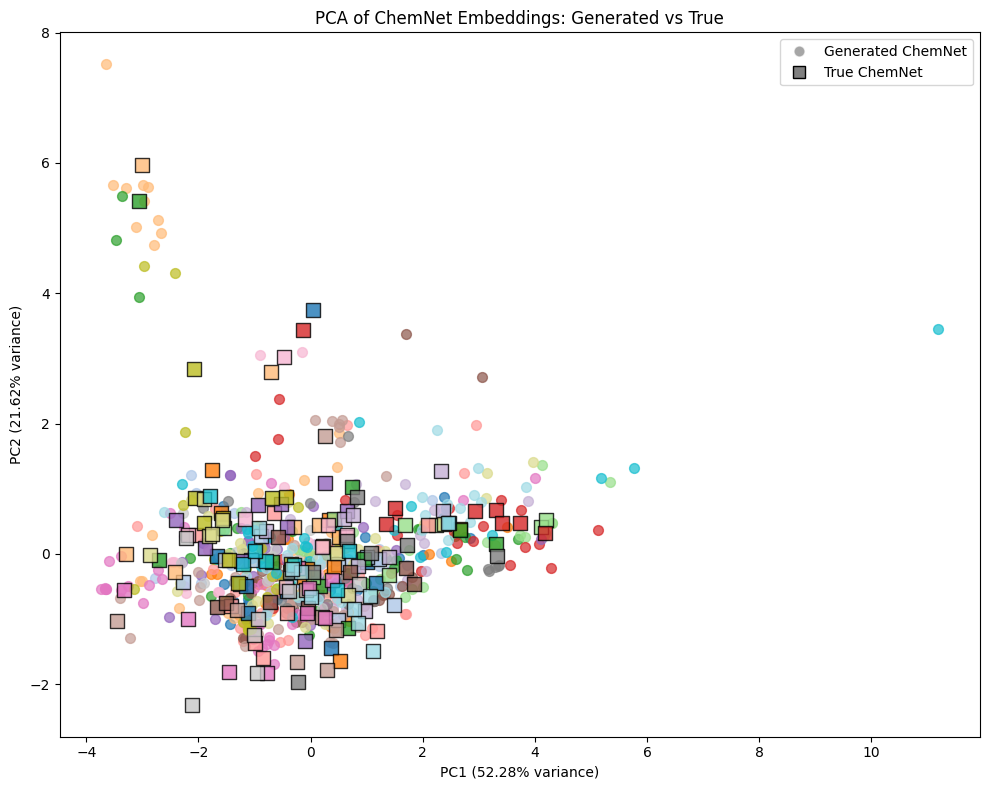

In [287]:

# PCA on ChemNet embeddings
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Fit PCA on generated embeddings and transform both generated and true embeddings
chemnet_pca = pca.fit_transform(chemnet_output)
true_chemnet_pca = pca.transform(true_chemnet_embeddings)

# Get SMILES for coloring (from your validation data)
val_smiles = test_data_df3_QQpos_copy['SMILES_spectra'].values  # Adjust if needed

# Create PCA visualization
plt.figure(figsize=(10, 8))

# Plot generated embeddings as circles, colored by SMILES
unique_smiles = np.unique(val_smiles)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))

for i, smiles in enumerate(unique_smiles):
    mask = val_smiles == smiles
    plt.scatter(chemnet_pca[mask, 0], chemnet_pca[mask, 1], 
               c=[colors[i]], alpha=0.7, s=50)

# Plot true embeddings as squares
for i, smiles in enumerate(true_smiles):
    if smiles in unique_smiles:
        color_idx = np.where(unique_smiles == smiles)[0][0]
        plt.scatter(true_chemnet_pca[i, 0], true_chemnet_pca[i, 1], 
                   c=[colors[color_idx]], marker='s', s=100, 
                   edgecolors='black', linewidths=1, alpha=0.8)

# Add legend with just the marker types
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                         markersize=8, label='Generated ChemNet', alpha=0.7),
                  Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                         markersize=8, label='True ChemNet', markeredgecolor='black')]

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of ChemNet Embeddings: Generated vs True')
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()
# # Show explained variance
# print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
# print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

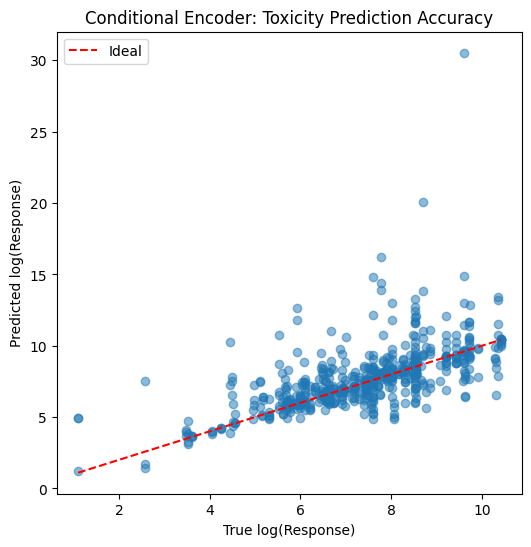

Toxicity Prediction MSE: 3.2200
Toxicity Prediction R²: -0.2584


In [288]:
# Toxicity prediction accuracy visualization
y_true_tox = y_val_tox.cpu().numpy().flatten()  # True toxicity values
y_pred_tox = tox_output  # Predicted toxicity values

plt.figure(figsize=(6, 6))
plt.scatter(y_true_tox, y_pred_tox, alpha=0.5)
plt.plot([y_true_tox.min(), y_true_tox.max()], [y_true_tox.min(), y_true_tox.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Conditional Encoder: Toxicity Prediction Accuracy')
plt.legend()
plt.show()

# Calculate metrics for toxicity prediction
from sklearn.metrics import mean_squared_error, r2_score
mse_tox = mean_squared_error(y_true_tox, y_pred_tox)
r2_tox = r2_score(y_true_tox, y_pred_tox)
print(f"Toxicity Prediction MSE: {mse_tox:.4f}")
print(f"Toxicity Prediction R²: {r2_tox:.4f}")

Total unique SMILES: 166
SMILES with >= 5 spectra: 18
Filtered generated embeddings shape: (146, 512)
Filtered true embeddings shape: (18, 512)


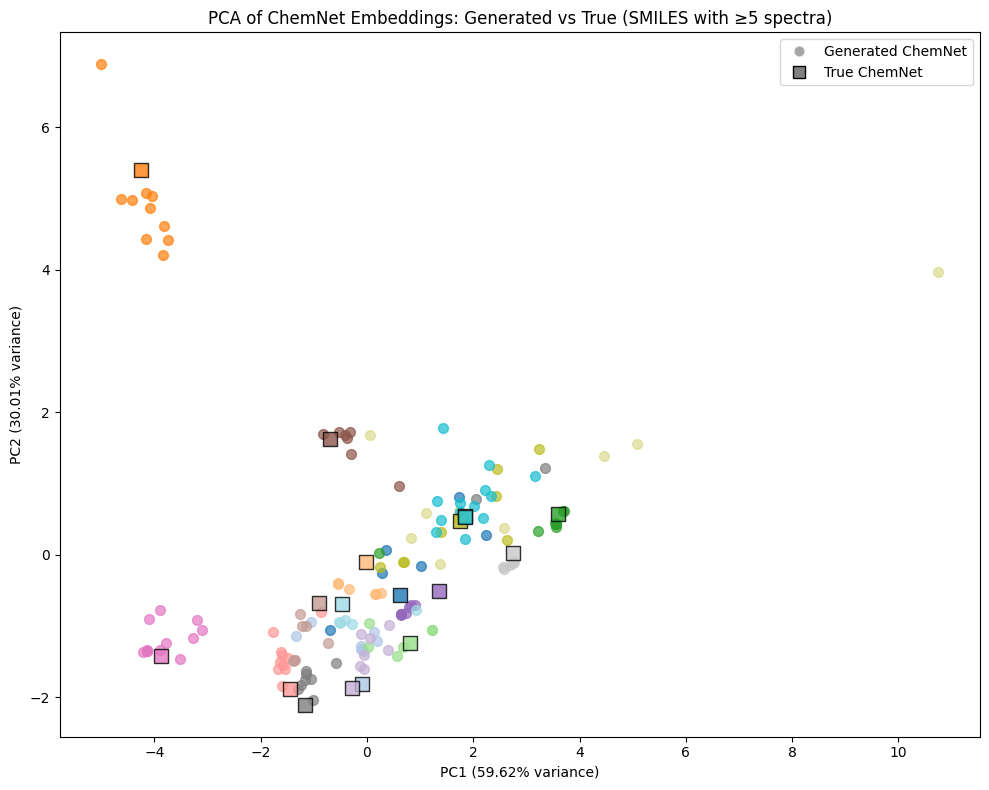

PCA Explained Variance: PC1=59.62%, PC2=30.01%
Total Explained Variance: 89.64%
Included SMILES: ['C=C(C)C1CC=C(C)CC1' 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12'
 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1' 'CC1=CC(=O)OC2=C1C=CC(O)=C2'
 'CCCCCCCC(=O)OCC(COC(=O)CCCCCCC)OC(=O)CCCCCCC' 'CCCOC(=O)NCCCN(C)C'
 'CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC' 'CC[C@@H](CO)NCCN[C@@H](CC)CO'
 'CN(C)CCC=C1C2=CC=CC=C2CSC2=C1C=CC=C2'
 'CN(CC1(C)CCCO1)S(=O)(=O)C1=CC=C(Cl)C(=C1)S(N)(=O)=O'
 'CN1C2=C(N(CCO)C=N2)C(=O)N(C)C1=O' 'CN1N(C(=O)C=C1C)C1=CC=CC=C1'
 'CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2' 'COCCOCCOCCOCCOC'
 'O=C(O)CCCCCCCC(=O)O' 'OCC(O)C(O)C(O)C(O)CO' 'OCC(O)C(O)C(O)CO'
 'S=C1NCCN1']


In [289]:
# Filter the spectra by the minimum number of spectra per SMILES
min_spectra_count = 5 

# Get SMILES and count occurrences of each SMILES and filter
val_smiles = test_data_df3_QQpos_copy['SMILES_spectra'].values  # Adjust if needed
smiles_counts = pd.Series(val_smiles).value_counts()
frequent_smiles = smiles_counts[smiles_counts >= min_spectra_count].index.tolist()

print(f"Total unique SMILES: {len(smiles_counts)}")
print(f"SMILES with >= {min_spectra_count} spectra: {len(frequent_smiles)}")

# Filter generated embeddings to only include frequent SMILES
frequent_mask = np.isin(val_smiles, frequent_smiles)
chemnet_output_filtered = chemnet_output[frequent_mask]
val_smiles_filtered = val_smiles[frequent_mask]

# Filter true embeddings to only include frequent SMILES
true_frequent_mask = np.isin(true_smiles, frequent_smiles)
true_chemnet_embeddings_filtered = true_chemnet_embeddings[true_frequent_mask]
true_smiles_filtered = true_smiles[true_frequent_mask]

print(f"Filtered generated embeddings shape: {chemnet_output_filtered.shape}")
print(f"Filtered true embeddings shape: {true_chemnet_embeddings_filtered.shape}")

# PCA on filtered ChemNet embeddings
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Fit PCA on filtered generated embeddings and transform both filtered datasets
chemnet_pca = pca.fit_transform(chemnet_output_filtered)
true_chemnet_pca = pca.transform(true_chemnet_embeddings_filtered)

# Create PCA visualization
plt.figure(figsize=(10, 8))
unique_frequent_smiles = np.unique(val_smiles_filtered)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_frequent_smiles)))

for i, smiles in enumerate(unique_frequent_smiles):
    mask = val_smiles_filtered == smiles
    plt.scatter(chemnet_pca[mask, 0], chemnet_pca[mask, 1], 
               c=[colors[i]], alpha=0.7, s=50)

for i, smiles in enumerate(true_smiles_filtered):
    if smiles in unique_frequent_smiles:
        color_idx = np.where(unique_frequent_smiles == smiles)[0][0]
        plt.scatter(true_chemnet_pca[i, 0], true_chemnet_pca[i, 1], 
                   c=[colors[color_idx]], marker='s', s=100, 
                   edgecolors='black', linewidths=1, alpha=0.8)

# Add legend with just the marker types
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                         markersize=8, label='Generated ChemNet', alpha=0.7),
                  Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                         markersize=8, label='True ChemNet', markeredgecolor='black')]

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA of ChemNet Embeddings: Generated vs True (SMILES with ≥{min_spectra_count} spectra)')
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

# Optional: Show explained variance and filtering stats
print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Included SMILES: {unique_frequent_smiles}")

In [290]:
# Generate output from the conditional encoder on super test set
x_super_tensor_df3_QQpos = x_super_tensor_df3_QQpos.to(next(cond_encoder_model_df3_QQpos.parameters()).device)
cond_encoder_model_df3_QQpos.eval()
with torch.no_grad():
    super_cond_encoder_output = cond_encoder_model_df3_QQpos(x_super_tensor_df3_QQpos)

# Separate the output into ChemNet embeddings (first 512) and toxicity prediction (last 1)
super_chemnet_output = super_cond_encoder_output[:, :512].cpu().numpy()  # First 512 dimensions
super_tox_output = super_cond_encoder_output[:, 512:].cpu().numpy().flatten()  # Last dimension

print(f"Super test ChemNet output shape: {super_chemnet_output.shape}")
print(f"Super test toxicity output shape: {super_tox_output.shape}")

# Load true ChemNet embeddings for comparison
true_chemnet_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
true_chemnet_embeddings = true_chemnet_df.iloc[:, 1:513].values  # Assuming columns 1-512 are embeddings
true_smiles = true_chemnet_df['SMILES'].values  # Adjust column name if different


Super test ChemNet output shape: (89, 512)
Super test toxicity output shape: (89,)


Super test frequent SMILES: 10
Filtered super test embeddings shape: (86, 512)
Filtered true embeddings shape: (10, 512)


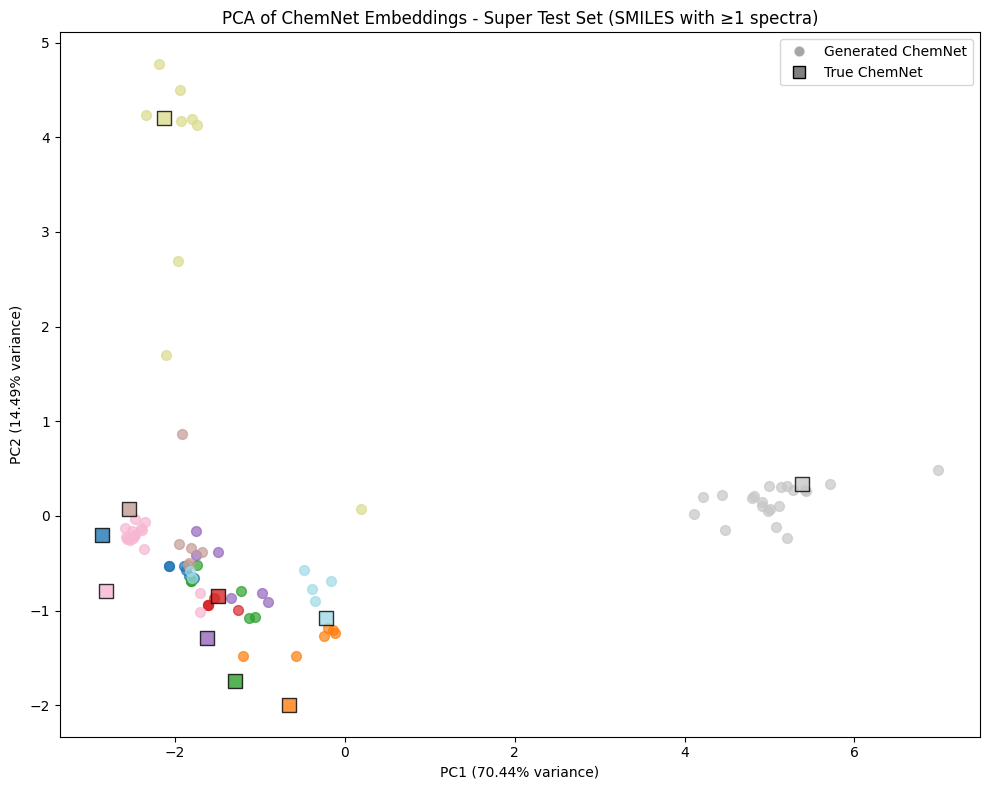

In [291]:
# Filter as before, but in this case I'll want all of them
min_spectra_count = 1  # EASILY CHANGEABLE VALUE

# Get SMILES for super test set
super_smiles = super_test_output_df3_QQpos_withEPA['SMILES_spectra'].values

# Count occurrences and filter (using original validation data for counting)
val_smiles = test_data_df3_QQpos_copy['SMILES_spectra'].values
smiles_counts = pd.Series(val_smiles).value_counts()
frequent_smiles = smiles_counts[smiles_counts >= min_spectra_count].index.tolist()

# Filter super test embeddings to only include frequent SMILES
super_frequent_mask = np.isin(super_smiles, frequent_smiles)
super_chemnet_output_filtered = super_chemnet_output[super_frequent_mask]
super_smiles_filtered = super_smiles[super_frequent_mask]

# Filter true embeddings to only include frequent SMILES that are also in super test
super_relevant_smiles = np.intersect1d(frequent_smiles, super_smiles)
true_super_mask = np.isin(true_smiles, super_relevant_smiles)
true_chemnet_embeddings_filtered = true_chemnet_embeddings[true_super_mask]
true_smiles_filtered = true_smiles[true_super_mask]

print(f"Super test frequent SMILES: {len(np.unique(super_smiles_filtered))}")
print(f"Filtered super test embeddings shape: {super_chemnet_output_filtered.shape}")
print(f"Filtered true embeddings shape: {true_chemnet_embeddings_filtered.shape}")

# PCA on filtered ChemNet embeddings
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Fit PCA on filtered super test embeddings and transform both datasets
super_chemnet_pca = pca.fit_transform(super_chemnet_output_filtered)
true_chemnet_pca = pca.transform(true_chemnet_embeddings_filtered)

# Create PCA visualization
plt.figure(figsize=(10, 8))

# Plot generated embeddings as circles, colored by SMILES
unique_super_smiles = np.unique(super_smiles_filtered)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_super_smiles)))

for i, smiles in enumerate(unique_super_smiles):
    mask = super_smiles_filtered == smiles
    plt.scatter(super_chemnet_pca[mask, 0], super_chemnet_pca[mask, 1], 
               c=[colors[i]], alpha=0.7, s=50)

# Plot true embeddings as squares
for i, smiles in enumerate(true_smiles_filtered):
    if smiles in unique_super_smiles:
        color_idx = np.where(unique_super_smiles == smiles)[0][0]
        plt.scatter(true_chemnet_pca[i, 0], true_chemnet_pca[i, 1], 
                   c=[colors[color_idx]], marker='s', s=100, 
                   edgecolors='black', linewidths=1, alpha=0.8)

# Add legend with just the marker types
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                         markersize=8, label='Generated ChemNet', alpha=0.7),
                  Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                         markersize=8, label='True ChemNet', markeredgecolor='black')]

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA of ChemNet Embeddings - Super Test Set (SMILES with ≥{min_spectra_count} spectra)')
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()



# # Show explained variance
# print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
# print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

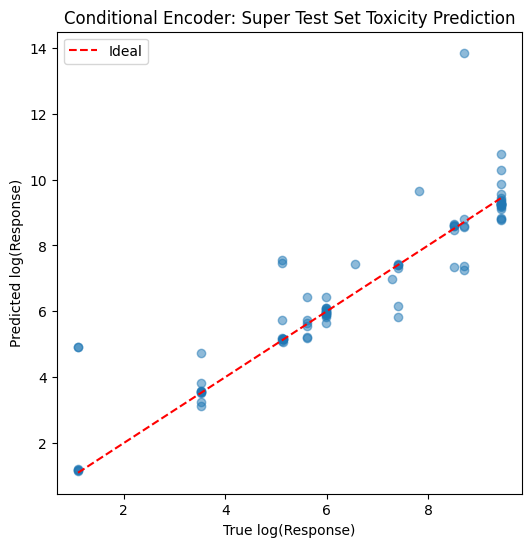

Super Test Toxicity Prediction MSE: 0.9999
Super Test Toxicity Prediction R²: 0.8304


In [292]:
# Toxicity prediction accuracy visualization for super test set
y_true_super_tox = super_test_output_df3_QQpos_withEPA['log_response'].values
y_pred_super_tox = super_tox_output

# Align arrays in case of size mismatch
min_length = min(len(y_true_super_tox), len(y_pred_super_tox))
y_true_super_tox = y_true_super_tox[:min_length]
y_pred_super_tox = y_pred_super_tox[:min_length]

plt.figure(figsize=(6, 6))
plt.scatter(y_true_super_tox, y_pred_super_tox, alpha=0.5)
plt.plot([y_true_super_tox.min(), y_true_super_tox.max()], [y_true_super_tox.min(), y_true_super_tox.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Conditional Encoder: Super Test Set Toxicity Prediction')
plt.legend()
plt.show()

# Calculate metrics for super test toxicity prediction
from sklearn.metrics import mean_squared_error, r2_score
mse_super_tox = mean_squared_error(y_true_super_tox, y_pred_super_tox)
r2_super_tox = r2_score(y_true_super_tox, y_pred_super_tox)
print(f"Super Test Toxicity Prediction MSE: {mse_super_tox:.4f}")
print(f"Super Test Toxicity Prediction R²: {r2_super_tox:.4f}")